# 1. <a id='toc1_'></a>[Project: Data Mining II (2025/26)](#toc0_)
**Group Number:** 12  
**Members:** 
- Beatriz Boura - 20250272
- Dinis Gaspar - 20221869
- Margarida Cruz - 20221929
---

## 1.1. <a id='toc1_1_'></a>[Project & Notebook Introduction](#toc0_)
In this notebook, we perform an Exploratory Data Analysis (EDA) on the Civic Support Alliance dataset. Our goal is to uncover insights, identify data quality issues, and design robust solutions to be implemented in our final modeling pipeline.

## 1.2. <a id='toc1_2_'></a>[Global Description of the Data](#toc0_)
The dataset consists of various attributes used to profile potential donors and their historical giving patterns. 

* **Numerical** variables capture continuous metrics such as donor age, neighborhood demographics (e.g., median home value), and detailed gift histories like lifetime donation counts and average amounts. 
* **Categorical** variables classify donors into qualitative groups, such as gender or urbanicity. Within these categories, certain fields are defined as **Ordinal** to reflect a natural ranking (such as socioeconomic status and income groups), while others are **Binary**, representing "yes/no" conditions like STAR donor status. 
* The **ID** field provides a unique reference for each donor, and the **Target (Binary)** variable serves as the primary outcome for prediction: whether the individual responded to the most recent campaign.

The table below provides a detailed breakdown and classification for every attribute included in this analysis.

| Attribute | Description | Variable Type |
| :--- | :--- | :--- |
| **CONTROL_NUMBER** | Unique identifier of each possible donor | ID |
| **DONOR_AGE** | Age as of last year's mail solicitation | Numerical |
| **URBANICITY** | Nature of the donor's location U= Urban C= City T = Town R = Rural S=Suburban | Categorical |
| **SES** | Code assigning each individual to one of 5 demographic profiles based on socioeconomic characteristics | Categorical (Ordinal) |
| **HOME_OWNER** | H if individual is a Homeowner, U if it is Unknown | Categorical |
| **DONOR_GENDER** | Gender of individual | Categorical |
| **INCOME_GROUP** | Code assigning each individual to one of 7 income group levels | Categorical (Ordinal) |
| **WEALTH_RATING** | Code assigning each individual to one of 10 wealth rating groups | Categorical (Ordinal) |
| **MEDIAN_HOME_VALUE** | Individuals' median home value in \$100's | Numerical |
| **MEDIAN_HOUSEHOLD_INCOME** | Individuals' median household income in \$100's | Numerical |
| **PCT_OWNER_OCCUPIED** | Percent of owner-occupied housing near where person lives | Numerical |
| **PER_CAPITA_INCOME** | Per Capita Income of neighborhood in which person lives | Numerical |
| **PCT_ATTRIBUTE1** | Percent of residents in person's neighborhood that are male and active military | Numerical |
| **PCT_ATTRIBUTE2** | Percent of residents in person's neighborhood that are male and veterans | Numerical |
| **PCT_ATTRIBUTE3** | Percent of residents in person's neighborhood that are Vietnam veterans | Numerical |
| **PCT_ATTRIBUTE4** | Percent of residents in person's neighborhood that are WW2 veterans | Numerical |
| **PEP_STAR** | If person achieved STAR donor status, given to individuals who have given to 3 consecutive campaigns. | Categorical (Binary) |
| **RECENT_STAR_STATUS** | If achieved STAR within last 4 years. | Categorical (Binary) |
| **RECENCY_STATUS_96NK** | Donor status: A (active - made their first donation more than 12 months ago and has made a donation in the last 12 months.); E (inactive - made a donation 25+ months ago.); F (first time - made their first donation in the last 6 months and has made just one donation.); L (lapsing - made their last donation between 13-24 months ago); N (new - made their first donation in the last 12 months and is not a First time donor); S (star donor) | Categorical |
| **FREQUENCY_STATUS_97NK** | Number of times donated in last period (The period of recency for all groups except L and E is the last 12 months. For L it is 13-24 months ago, and for E it is 25-36 months ago). | Numerical |
| **RECENT_RESPONSE_PROP** | Proportion of responses to the individual to the number of (card or other) solicitations from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_GIFT_AMT** | Average donation from the individual to the charitable organization in the last four years. | Numerical |
| **RECENT_CARD_RESPONSE_PROP** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_CARD_GIFT_AMT** | Average donation from the individual in response to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_RESPONSE_COUNT** | Number of times the individual has responded to a promotion (card or other) from the charitable organization in the last four years | Numerical |
| **RECENT_CARD_RESPONSE_COUNT** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years. | Numerical |
| **MONTHS_SINCE_LAST_PROM_RESP** | Number of months since the individual has responded to a promotion by the charitable organization | Numerical |
| **LIFETIME_CARD_PROM** | Total number of card promotions sent to the individual by the charitable organization | Numerical |
| **LIFETIME_PROM** | Total number of promotions (card or other) sent to the individual by the charitable organization | Numerical |
| **LIFETIME_GIFT_AMOUNT** | Total lifetime donation amount from the individual to the charitable organization | Numerical |
| **LIFETIME_GIFT_COUNT** | Total number of donations from the individual to the charitable organization | Numerical |
| **LIFETIME_MAX_GIFT_AMT** | Maximum donation amount from individual | Numerical |
| **LIFETIME_MIN_GIFT_AMT** | Minimum donation amount from individual | Numerical |
| **LAST_GIFT_AMT** | Amount donated in the individuals most recent donation | Numerical |
| **CARD_PROM_12** | Number of card promotions sent to the individual by the charitable organization in the last 12 months | Numerical |
| **NUMBER_PROM_12** | Number of promotions (card or other) sent to the individual by the charitable organization in the last 12 months | Numerical |
| **MONTHS_SINCE_LAST_GIFT** | Number of months since the most recent donation from the individual to the charitable organization | Numerical |
| **MONTHS_SINCE_FIRST_GIFT** | Number of months since the first donation from the individual to the charitable organization | Numerical |
| **FILE_CARD_GIFT** | Lifetime average donation from the individual in response to all card solicitations from the charitable organization | Numerical |
| **CHILDREN** | Number of children the individual has | Numerical |
| **TARGET_B** | Whether person has donated in the last year's campaign or not (1 or 0 respectively) | Target (Binary) |

**Table of contents**<a id='toc0_'></a>    
1. [Project: Data Mining II (2025/26)](#toc1_)    
1.1. [Project & Notebook Introduction](#toc1_1_)    
1.2. [Global Description of the Data](#toc1_2_)    
2. [Imports](#toc2_)    
3. [Analysis of Row uniqueness](#toc3_)    
4. [Exploratory Data Analysis](#toc4_)    
4.1. [Missing Values](#toc4_1_)    
4.2. [Categorical columns](#toc4_2_)    
4.2.1. [Value consistency evaluation](#toc4_2_1_)    
4.2.2. [Distributions and target proportions](#toc4_2_2_)    
4.2.3. [Statistical test - Chi-square independence test](#toc4_2_3_)    
4.3. [Numerical Columns](#toc4_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=3
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 2. <a id='toc2_'></a>[Imports](#toc0_)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from utils_EDA import (outlier_count_IQR, outlier_filter_IQR,
                            bar_charts_categorical, distribution_plot_grid,
                            cor_heatmap)

In [4]:
%cd ..
train = pd.read_csv('Datasets/donors_train.csv')
%cd EDA
train.head()

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\EDA


,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
0,61745,4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,...,17.50,NaN,0.000,2.0,0.154,0.0,2,T,NaN,1
1,112703,3.0,2.0,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1
2,166437,4.0,2.0,NaN,F,7.0,3.0,H,4.0,10.0,...,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0
3,170621,4.0,NaN,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0
4,44428,6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,...,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0


# 3. <a id='toc3_'></a>[Analysis of Row uniqueness](#toc0_)

We'll start by checking whether the training dataset contains any repeated rows. Firstly, checking the uniqueness of the donor identifier column "CONTROL_NUMBER" and then we'll check whether there are fully repeated feature combinations across different identifiers.

In [5]:
train['CONTROL_NUMBER'].duplicated().sum()

np.int64(0)

We can conclude that there are no repeated unique identifiers of each donor, this means we can and will use the CONTROL_NUMBER variable as the index for our Dataframe.

In [6]:
train.set_index('CONTROL_NUMBER', inplace=True)

In [7]:
train.duplicated().sum()

np.int64(0)

From the above cell, we can be certain that all donor profiles are unique and not repeated. Now, we will start to look deeper at the actual data, with regards to column-specific issues and insights. 

# 4. <a id='toc4_'></a>[Exploratory Data Analysis](#toc0_)

We'll first look at the informational summary of our dataset.

In [8]:
train.info()

<class 'pandas.DataFrame'>
Index: 13560 entries, 61745 to 45722
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CARD_PROM_12                 13297 non-null  float64
 1   CHILDREN                     13298 non-null  float64
 2   DONOR_AGE                    10006 non-null  float64
 3   DONOR_GENDER                 13288 non-null  str    
 4   FILE_CARD_GIFT               13300 non-null  float64
 5   FREQUENCY_STATUS_97NK        13278 non-null  float64
 6   HOME_OWNER                   13274 non-null  str    
 7   INCOME_GROUP                 10271 non-null  float64
 8   LAST_GIFT_AMT                13299 non-null  float64
 9   LIFETIME_CARD_PROM           13300 non-null  float64
 10  LIFETIME_GIFT_AMOUNT         13287 non-null  float64
 11  LIFETIME_GIFT_COUNT          13285 non-null  float64
 12  LIFETIME_MAX_GIFT_AMT        13300 non-null  float64
 13  LIFETIME_MIN_GIFT_AMT       

We right away can conclude that all variables described in the dataset description section of the guidelines are present in the dataset. We can also conlude that most (if not all) of the variables have missing values. Additionally, the SES variable which is categorical and we expected to be ordinally encoded has been assigned a string datatype, we will look further into this when we explore our categorical columns.

As this is a binary classification problem, we'll now check  whether the target variable is balanced.

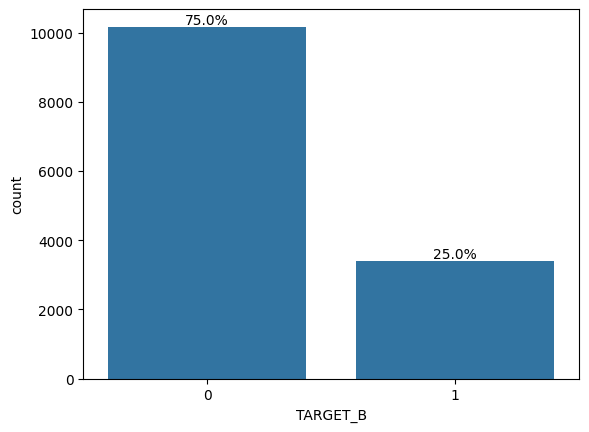

In [9]:
# Create the base plot
ax = sns.countplot(data=train, x='TARGET_B')
# Calculate the percentages
labels = [f'{(v.get_height()/len(train['TARGET_B']))*100:.1f}%' for v in ax.patches]
# Add the percentage labels
ax.bar_label(ax.containers[0], labels=labels)
plt.show()

It's now clear that we are dealing with an unbalanced target, this means that relevant precautions must be considered during modeling to ensure that the model can correctly identify cases where donor donated and didn't donate correctly. These precautions include using the appropriate metrics, such as F1 score which is the metric we will use since it's also (due to this imbalance) the metric used in the kaggle competitons, but also techniques such as applying class wieghts in models that support it. <p>
Now that we understand the imbalance in the target, let's start looking deeper into our features.

In [10]:
# These lists will allow us to filter the dataset by the relevant datatype for
# each type of analysis based on the assignments explained in the global description
# of the data

# Numerical Variables
num_cols = [
    "DONOR_AGE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "MONTHS_SINCE_LAST_PROM_RESP",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_CARD_GIFT",
    "CHILDREN"
]

# Categorical Variables
cat_cols = [
    "URBANICITY",
    "SES",
    "HOME_OWNER",
    "DONOR_GENDER",
    "INCOME_GROUP",
    "WEALTH_RATING",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "RECENCY_STATUS_96NK",
]

## 4.1. <a id='toc4_1_'></a>[Missing Values](#toc0_)

In this section, the presence of missing values in the data will be evaluated.

In [11]:
pd.merge(train.isna().sum().to_frame('N Missing'), (train.isna().sum().to_frame('% Missing') / len(train) * 100).round(2),
         left_index=True,
         right_index=True)

,N Missing,% Missing
CARD_PROM_12,263,1.94
CHILDREN,262,1.93
DONOR_AGE,3554,26.21
DONOR_GENDER,272,2.01
FILE_CARD_GIFT,260,1.92
FREQUENCY_STATUS_97NK,282,2.08
HOME_OWNER,286,2.11
INCOME_GROUP,3289,24.26
LAST_GIFT_AMT,261,1.92
LIFETIME_CARD_PROM,260,1.92


We can now conclude that all of the variables have a residual amount of missing values, around 2%. Furthermore, there are three variables with much higher rates of missingness, INCOME_GROUP and DONOR_AGE with around 25% missing data and WEALTH_RATING with just over 45% missing values. <p> Below, a row-level analysis of missing values will be performed. 

In [12]:
train.isna().sum(axis=1).value_counts()

1    4324
2    3592
0    2345
3    2136
4     840
5     265
6      52
7       5
8       1
Name: count, dtype: int64

The highest rate of missing values at a row level is around 20% and the very large majority of rows contain less than 10% missing information, with around 15% of rows not containing any missing values. 

In [13]:
train[train.isna().sum(axis=1) >= 5].isna().sum()

CARD_PROM_12                    24
CHILDREN                        26
DONOR_AGE                      280
DONOR_GENDER                    23
FILE_CARD_GIFT                  25
FREQUENCY_STATUS_97NK           19
HOME_OWNER                      31
INCOME_GROUP                   246
LAST_GIFT_AMT                   19
LIFETIME_CARD_PROM              19
LIFETIME_GIFT_AMOUNT            19
LIFETIME_GIFT_COUNT             20
LIFETIME_MAX_GIFT_AMT           14
LIFETIME_MIN_GIFT_AMT           37
LIFETIME_PROM                   15
MEDIAN_HOME_VALUE               22
MEDIAN_HOUSEHOLD_INCOME         26
MONTHS_SINCE_FIRST_GIFT         31
MONTHS_SINCE_LAST_GIFT          34
MONTHS_SINCE_LAST_PROM_RESP     41
NUMBER_PROM_12                  26
PCT_ATTRIBUTE1                  26
PCT_ATTRIBUTE2                  22
PCT_ATTRIBUTE3                  23
PCT_ATTRIBUTE4                  18
PCT_OWNER_OCCUPIED              27
PEP_STAR                        34
PER_CAPITA_INCOME               24
RECENCY_STATUS_96NK 

Looking at the distribution of missing values among rows with higher than 10% missingess, there are no clear patterns as the only columns with more common missing values in this segment are also the ones with more common missing values in the overall data.

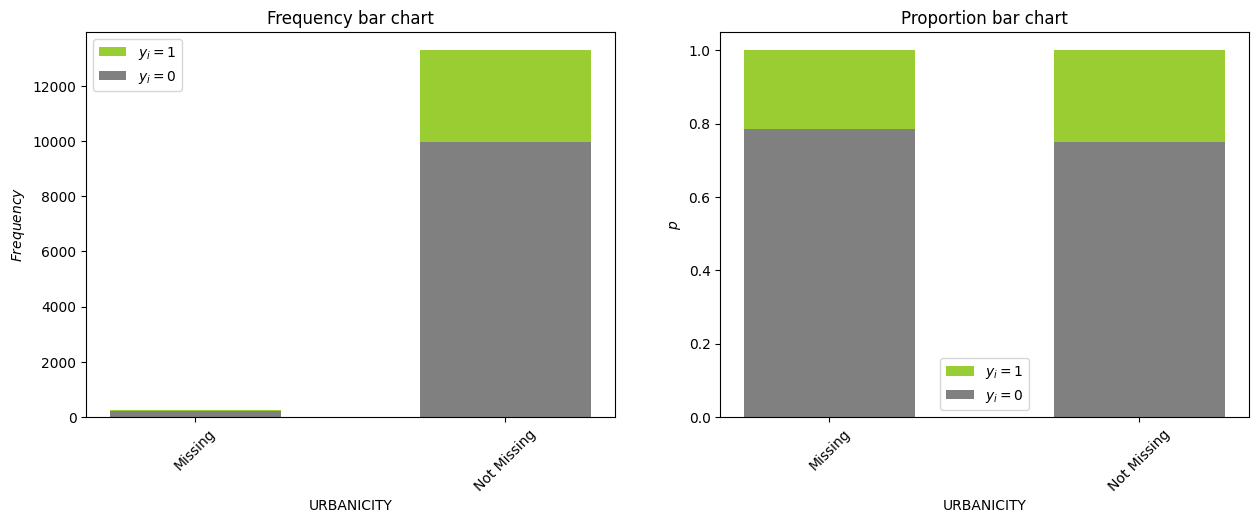

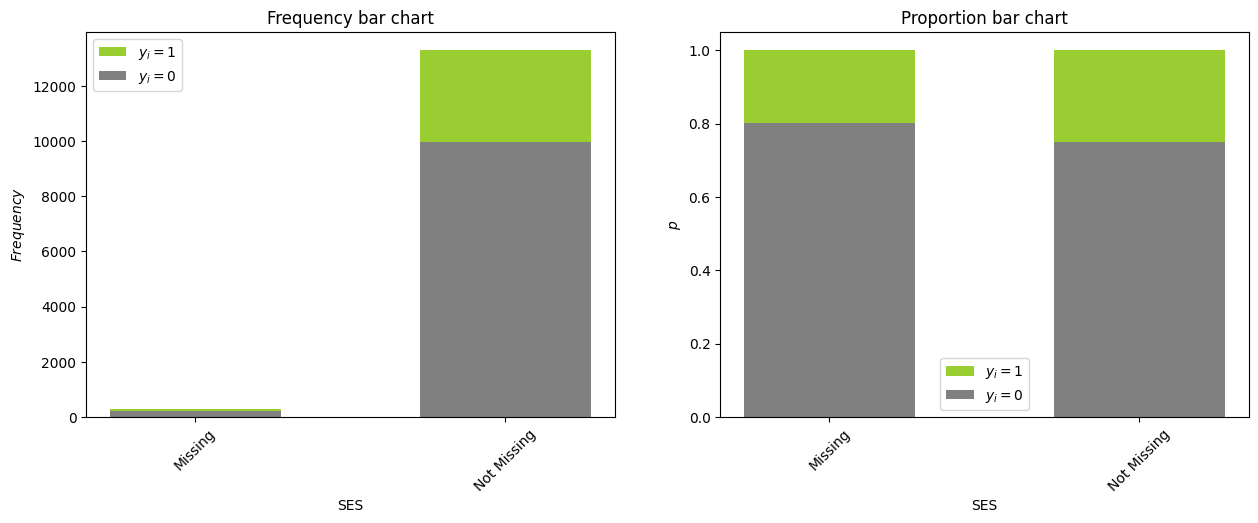

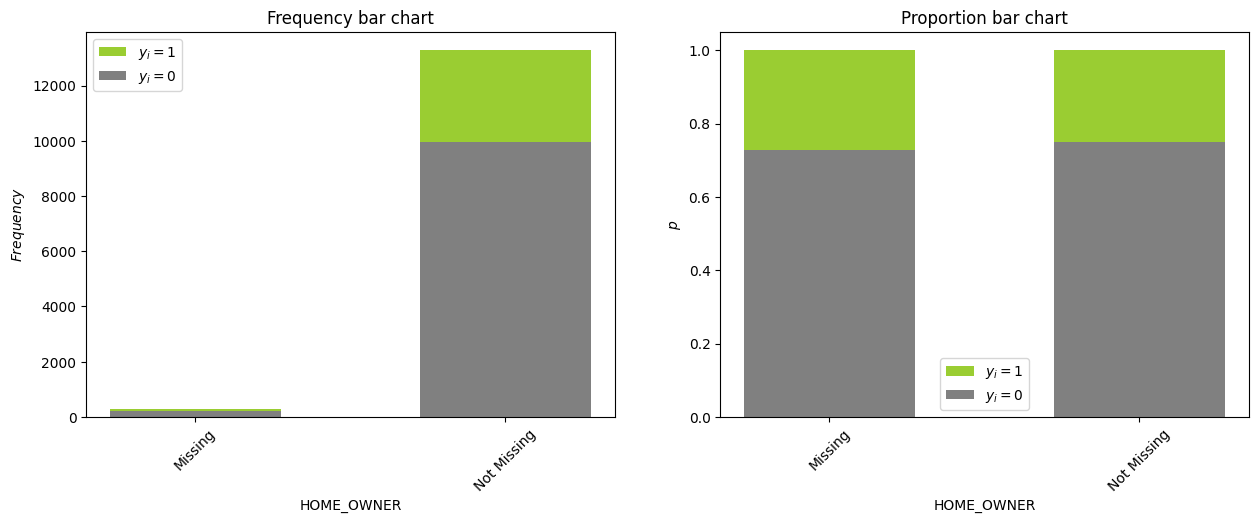

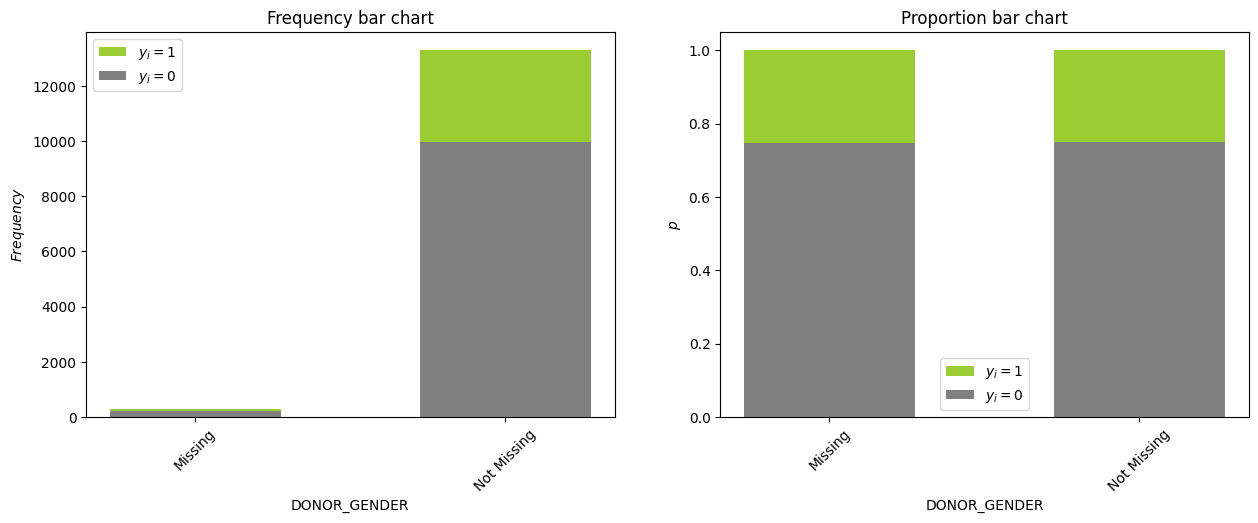

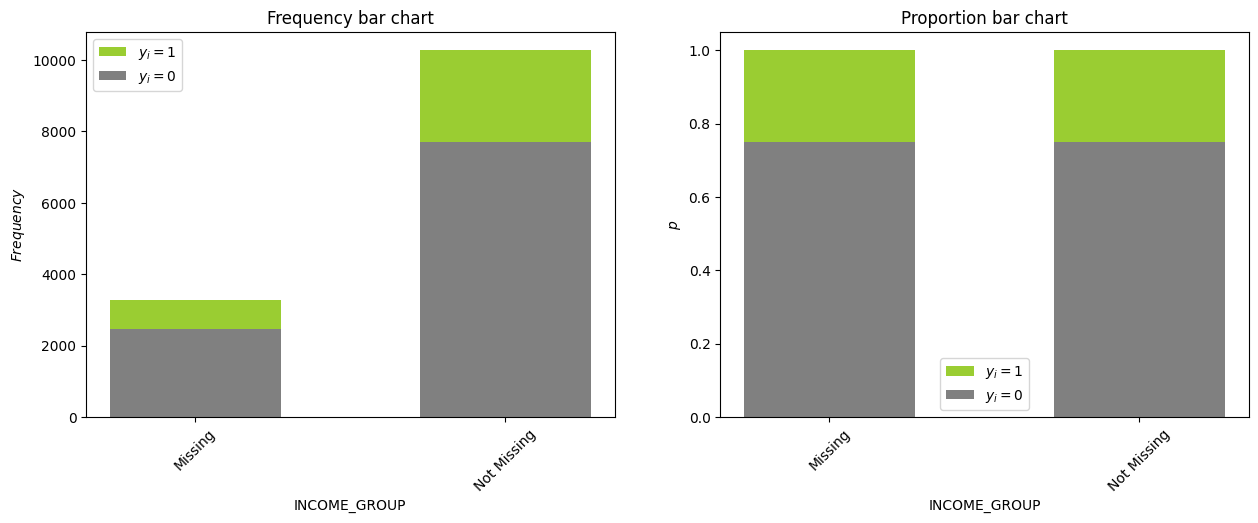

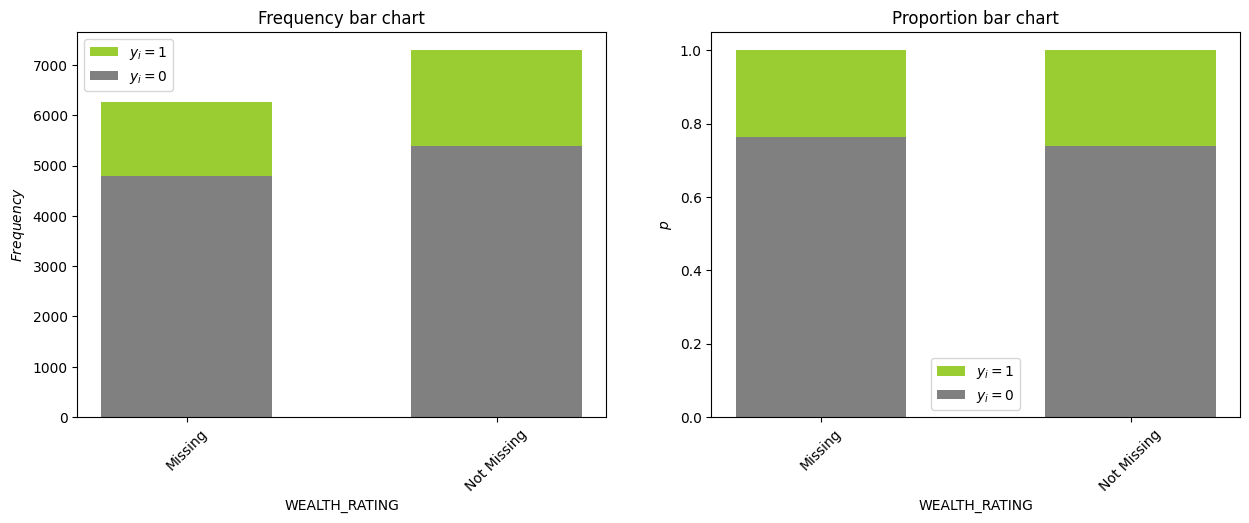

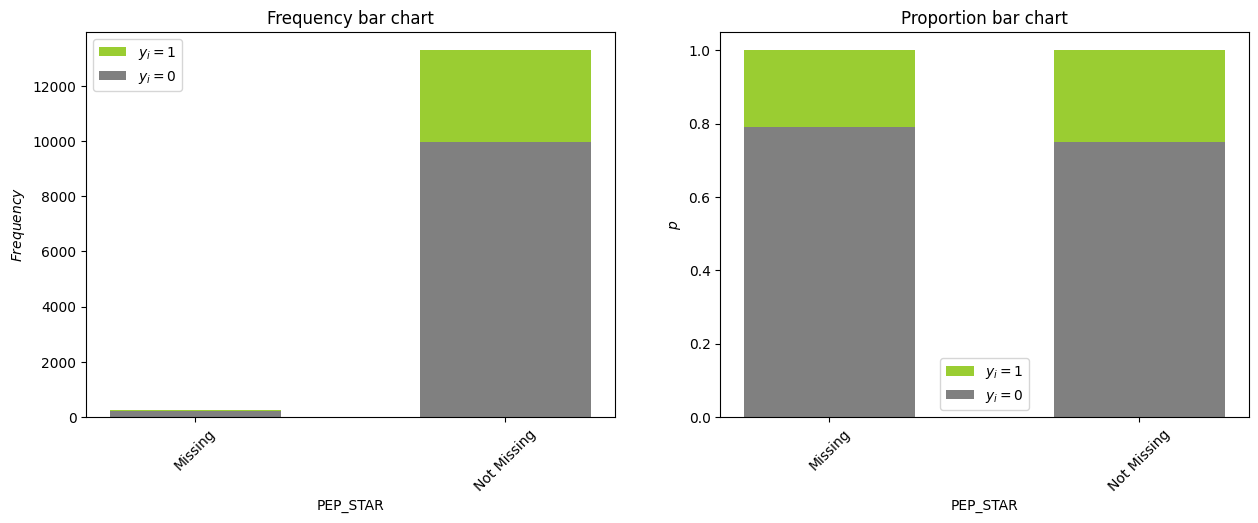

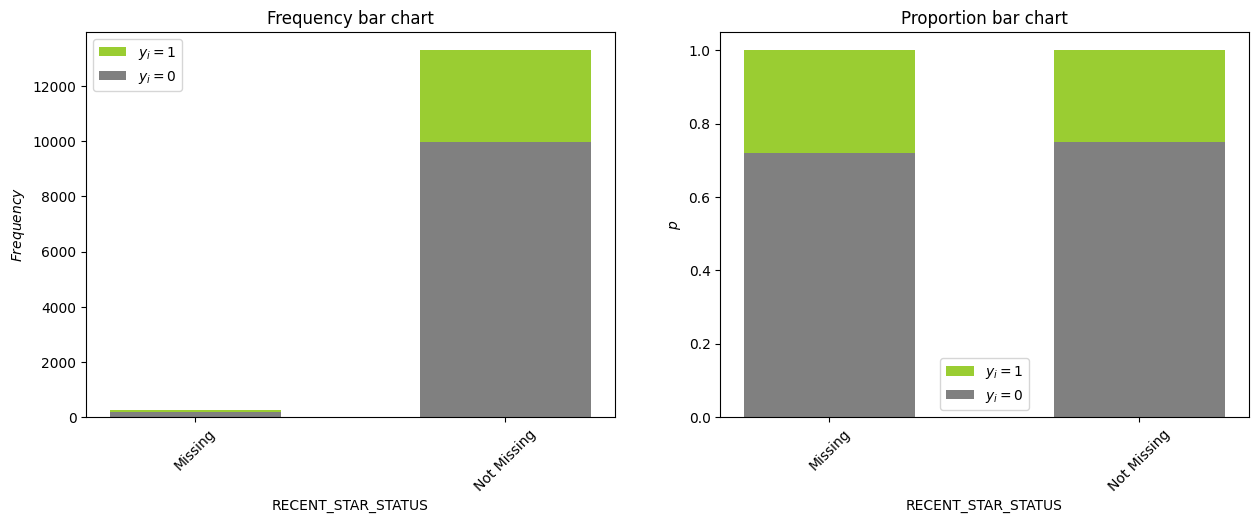

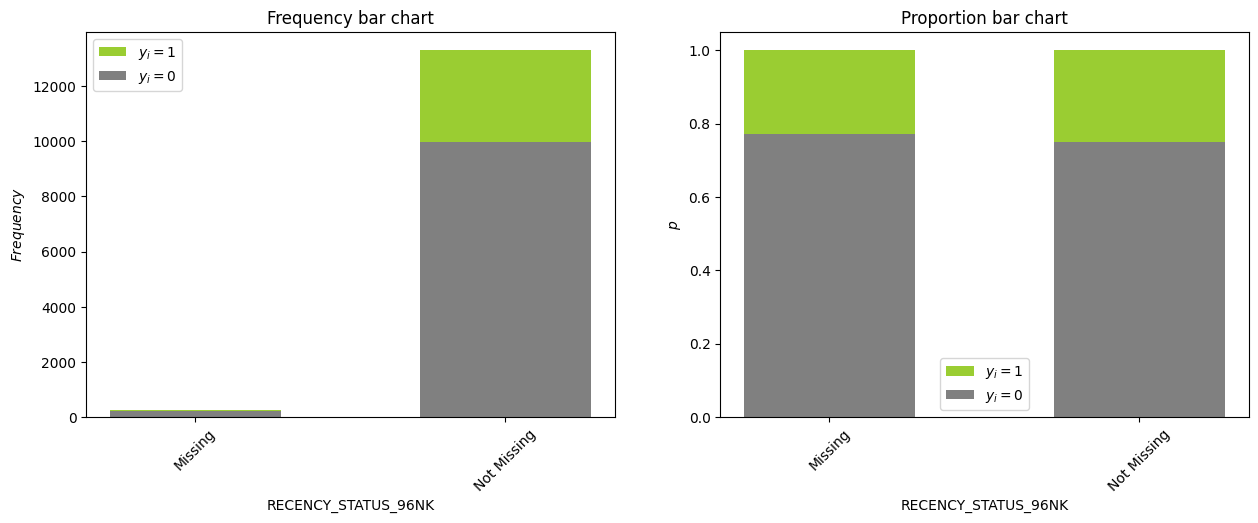

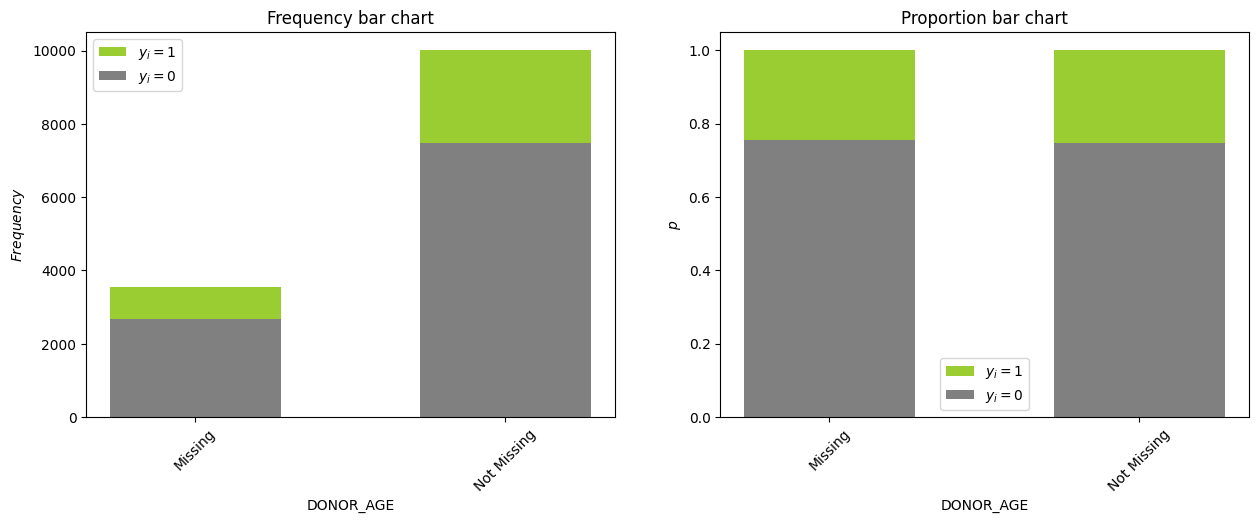

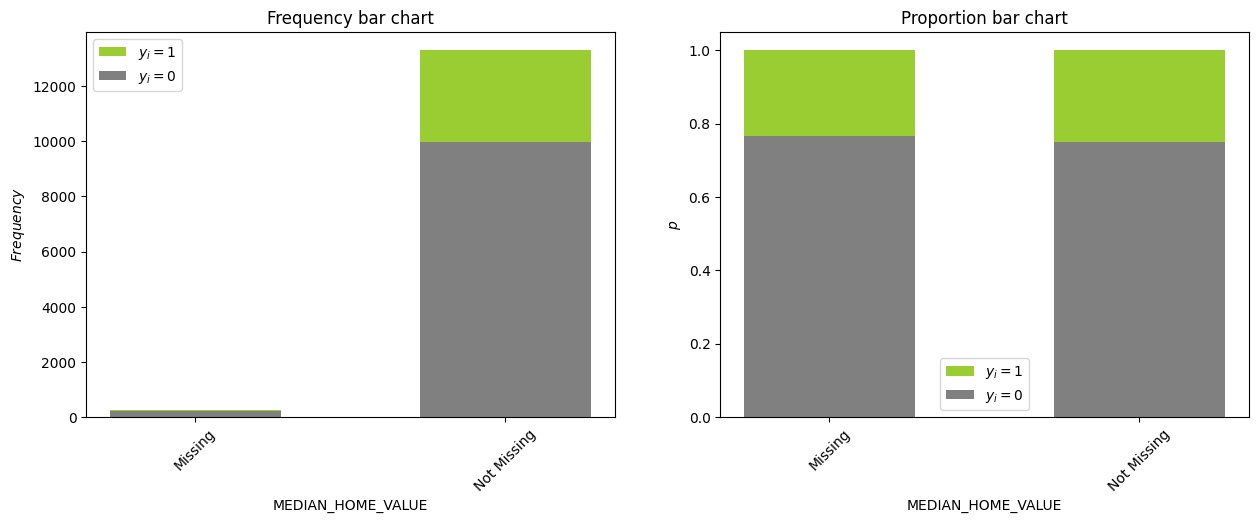

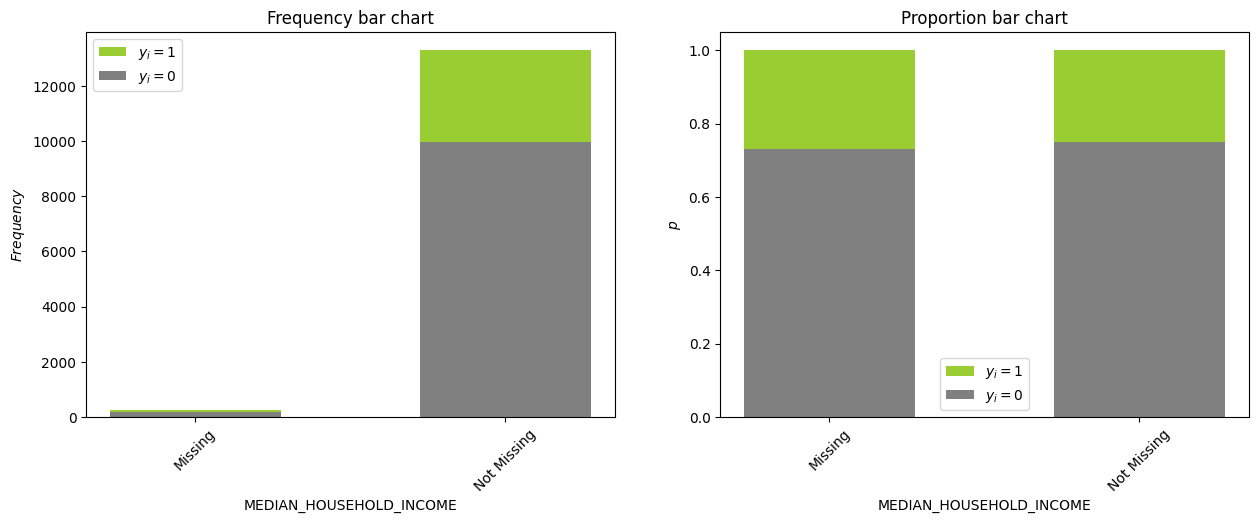

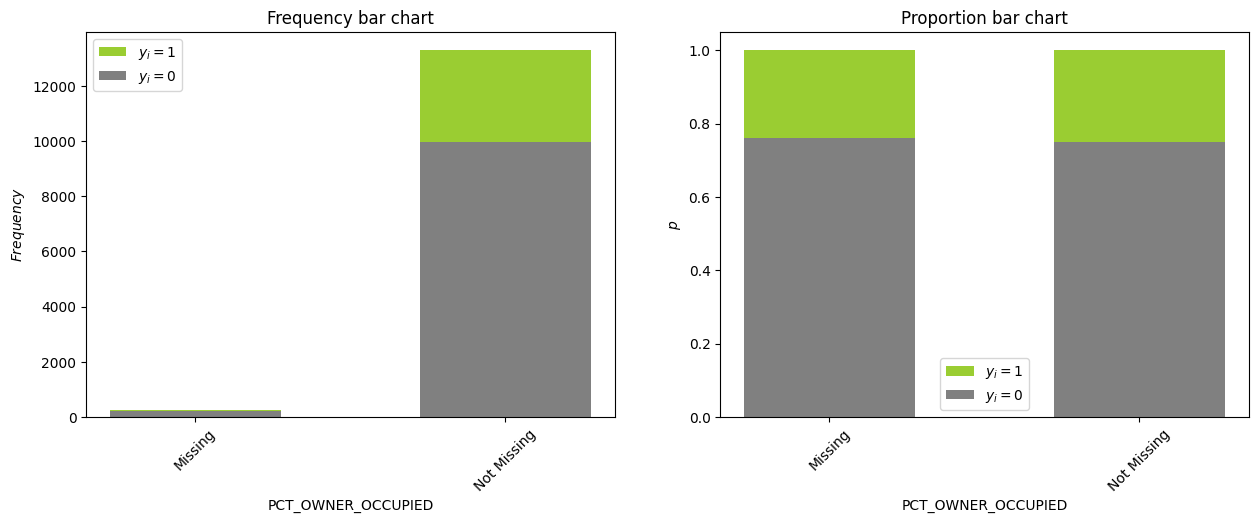

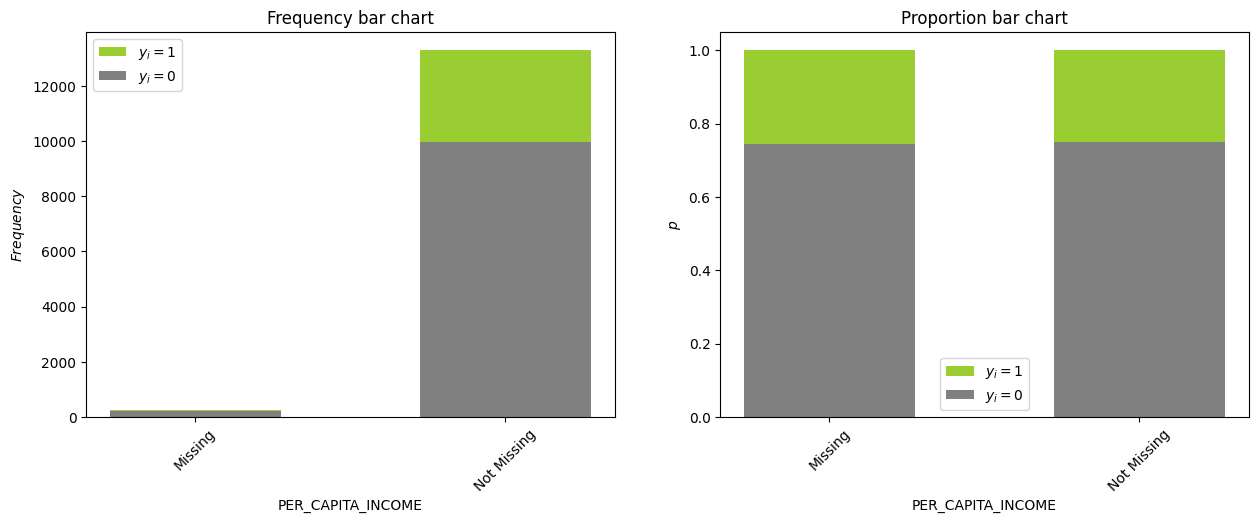

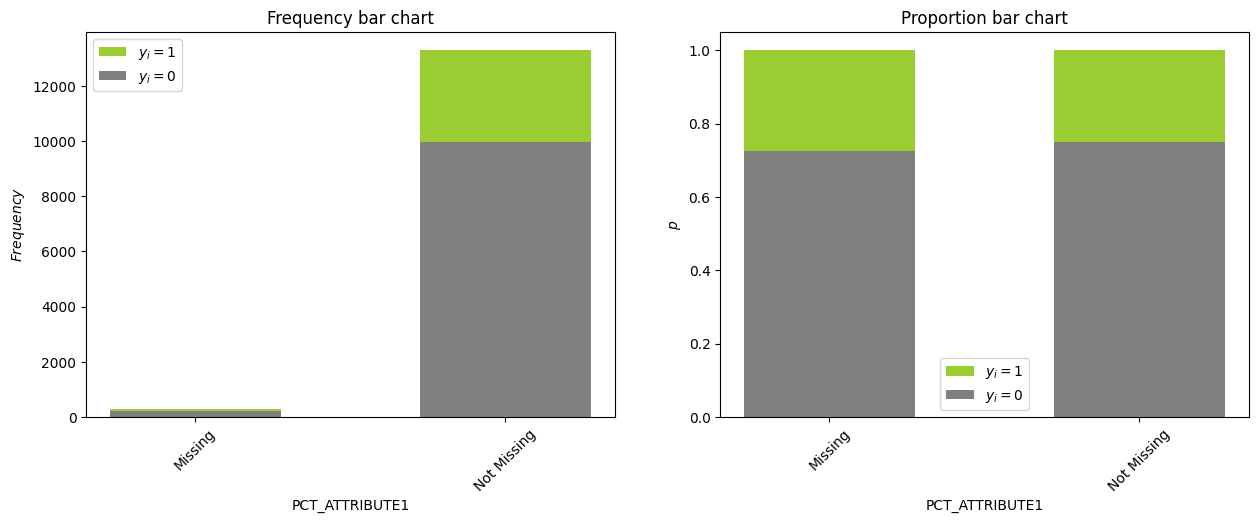

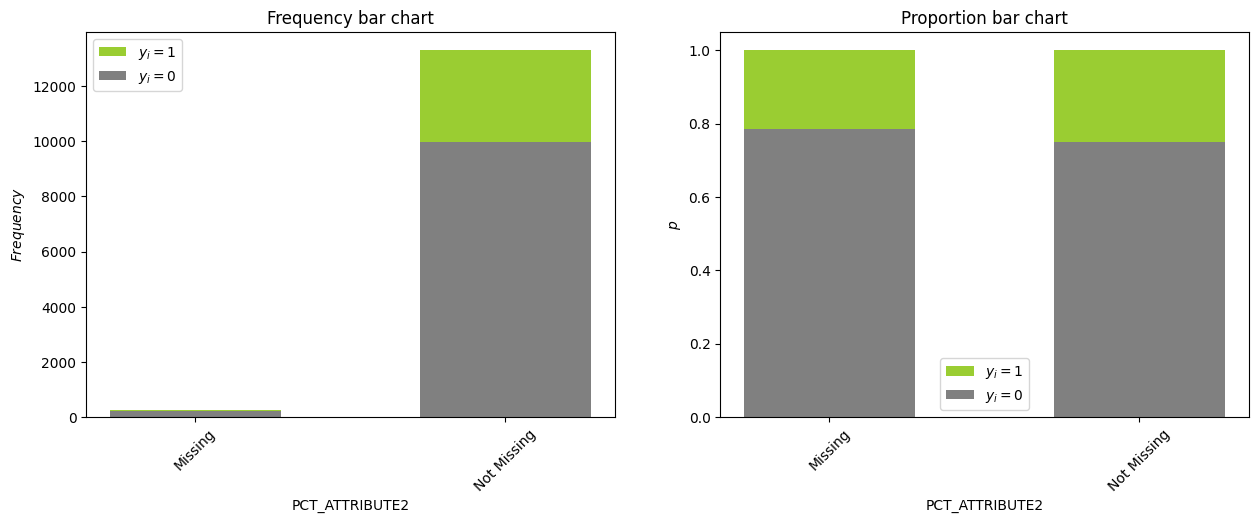

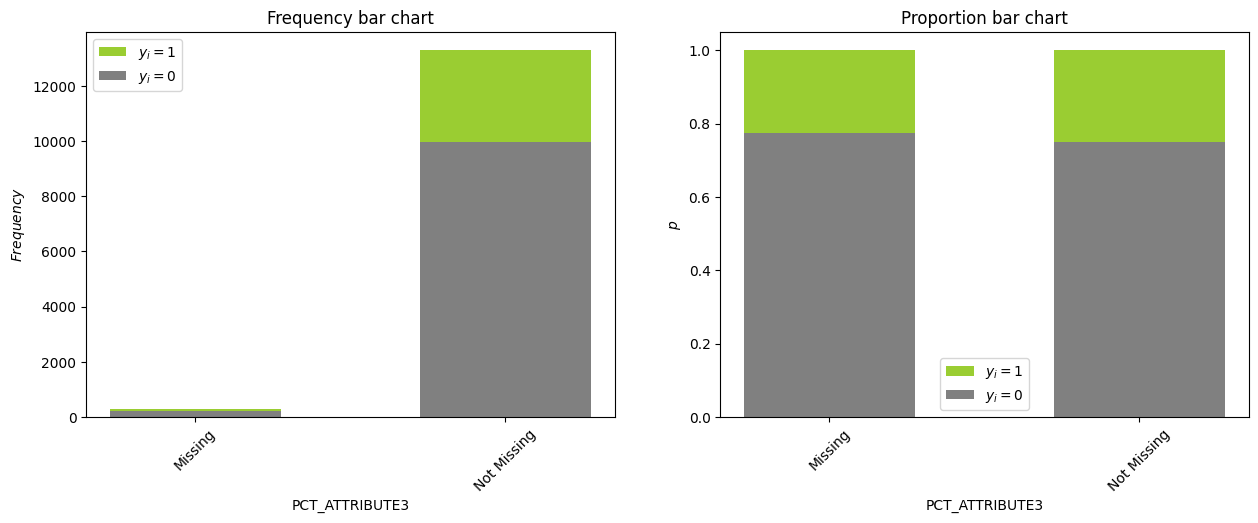

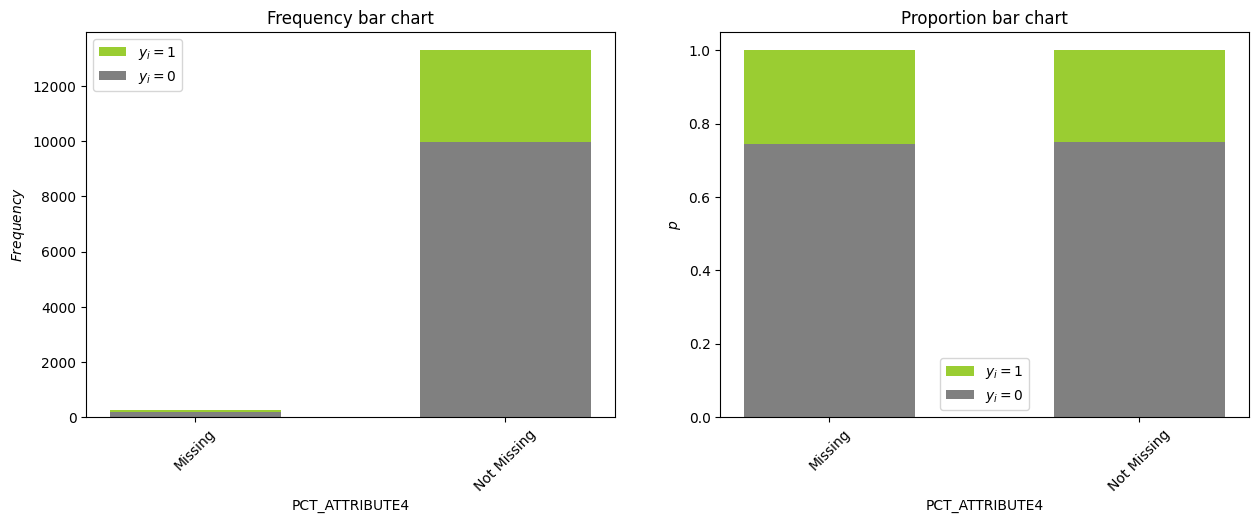

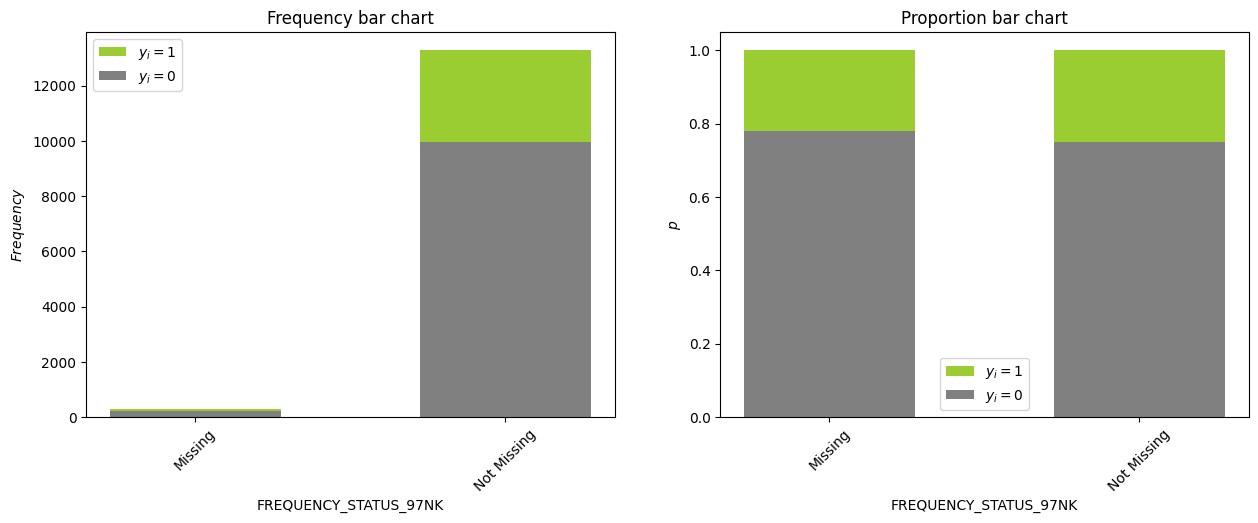

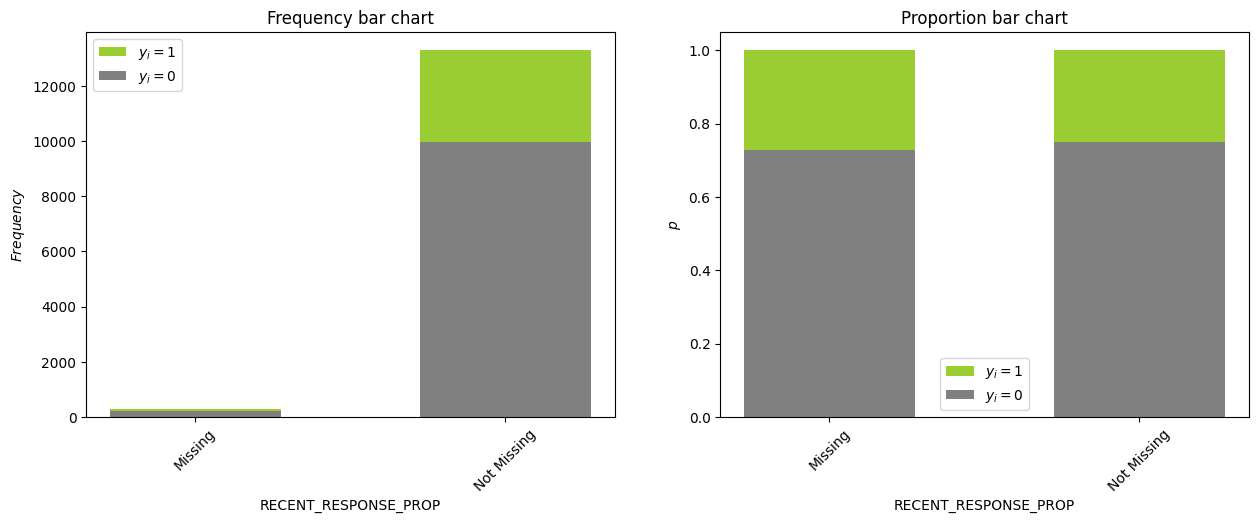

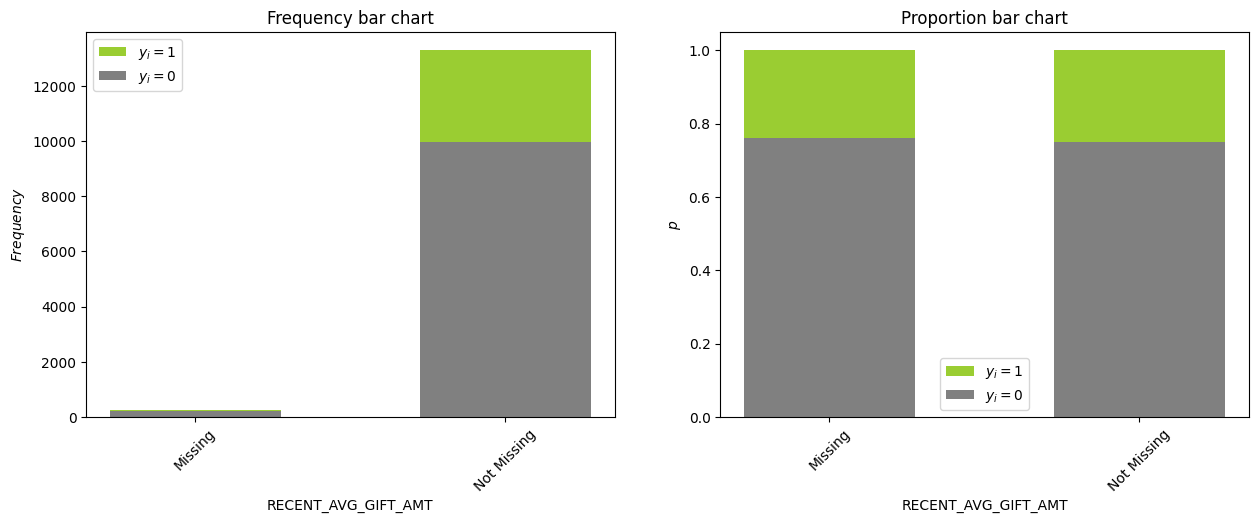

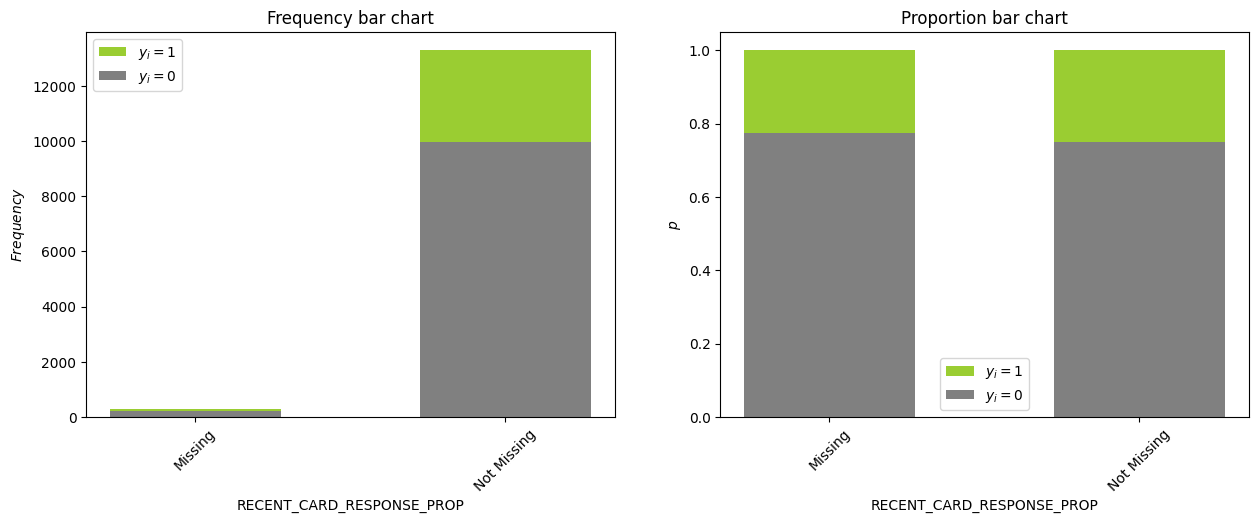

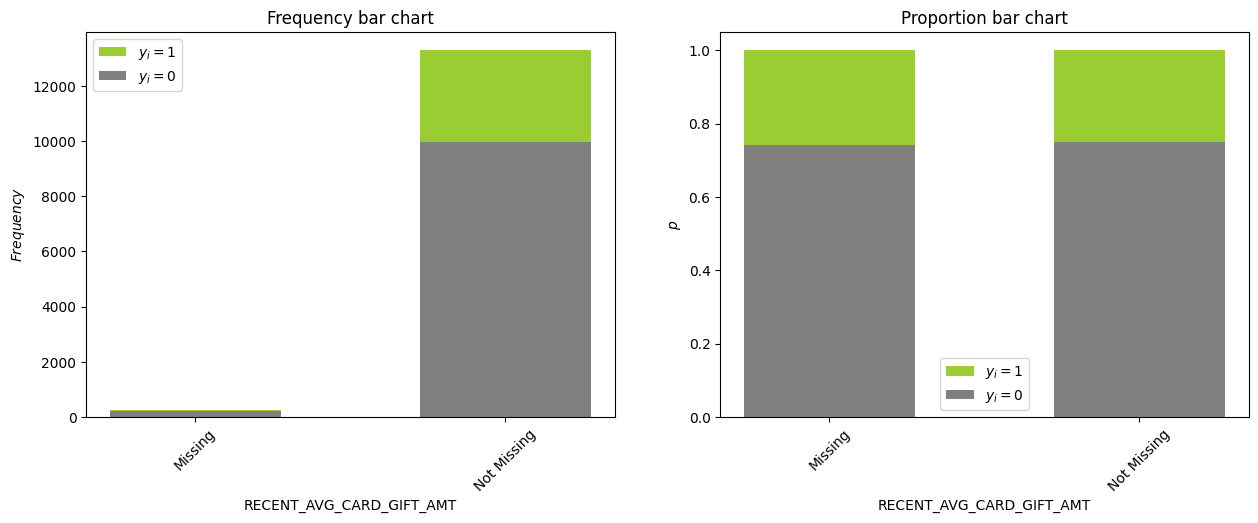

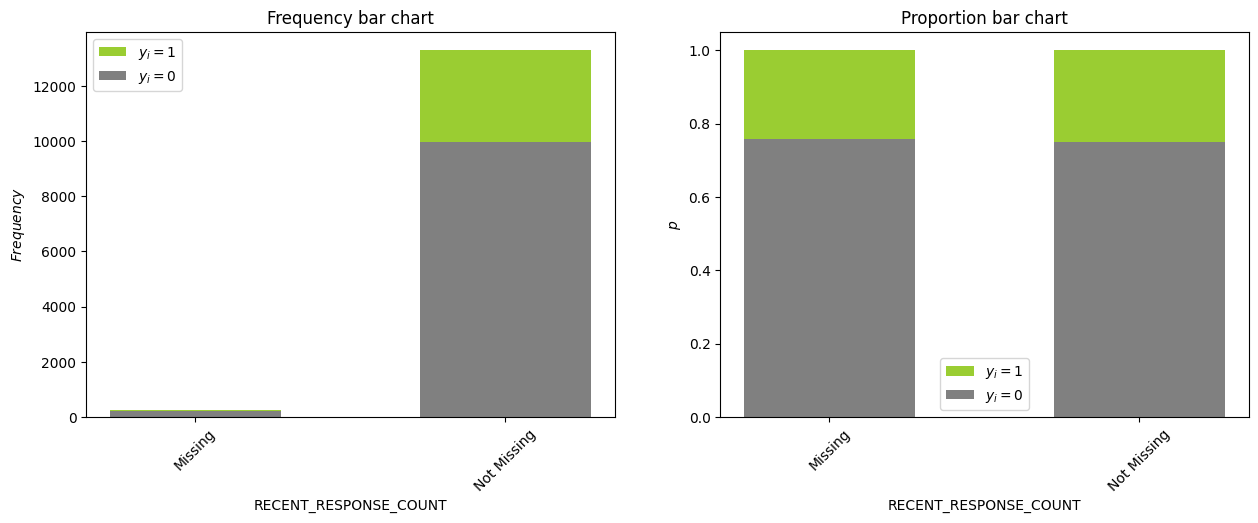

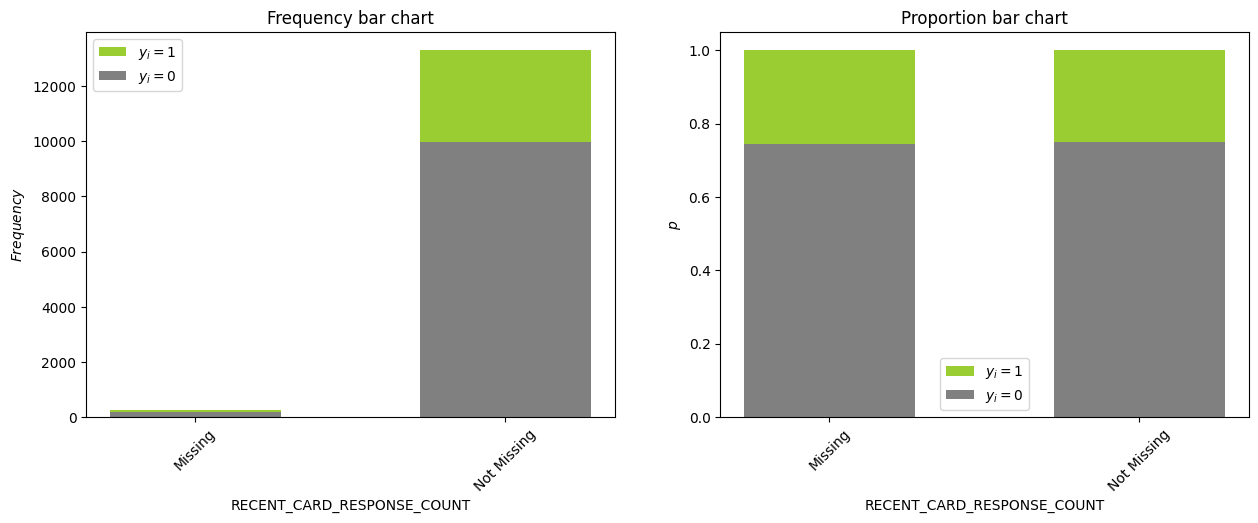

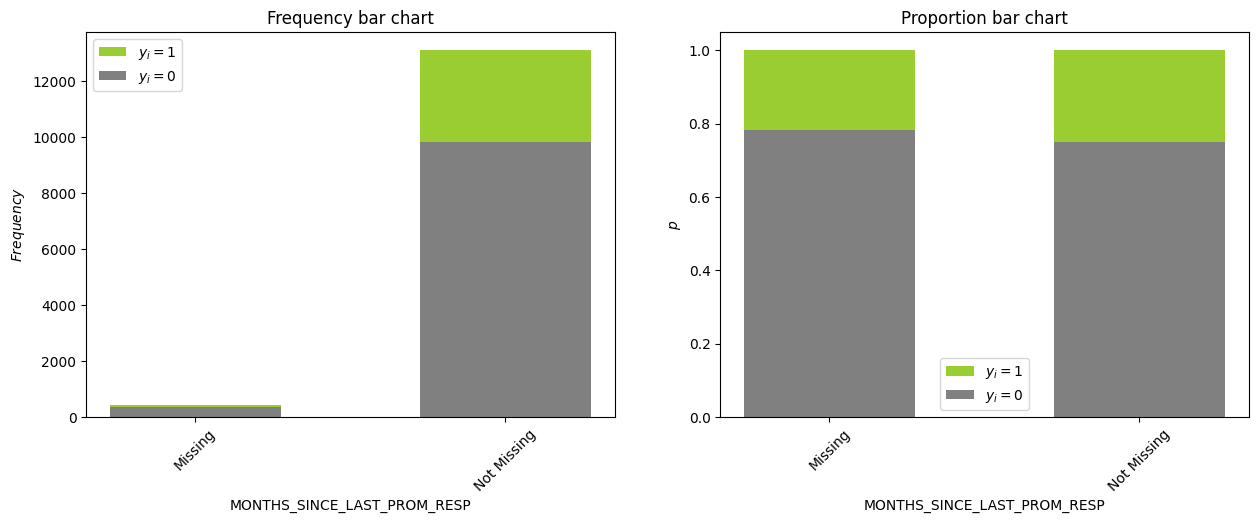

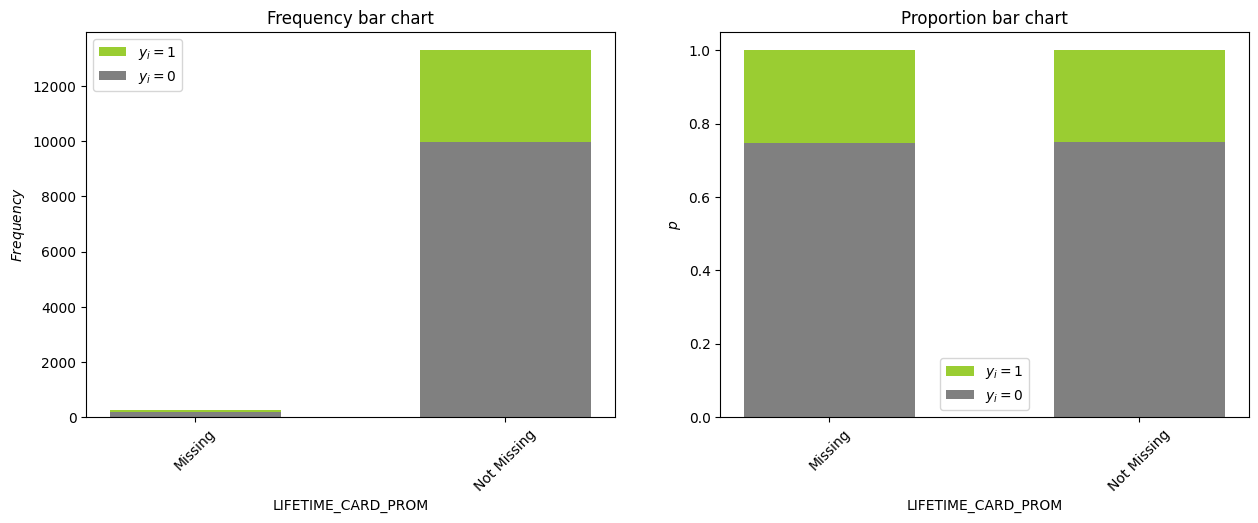

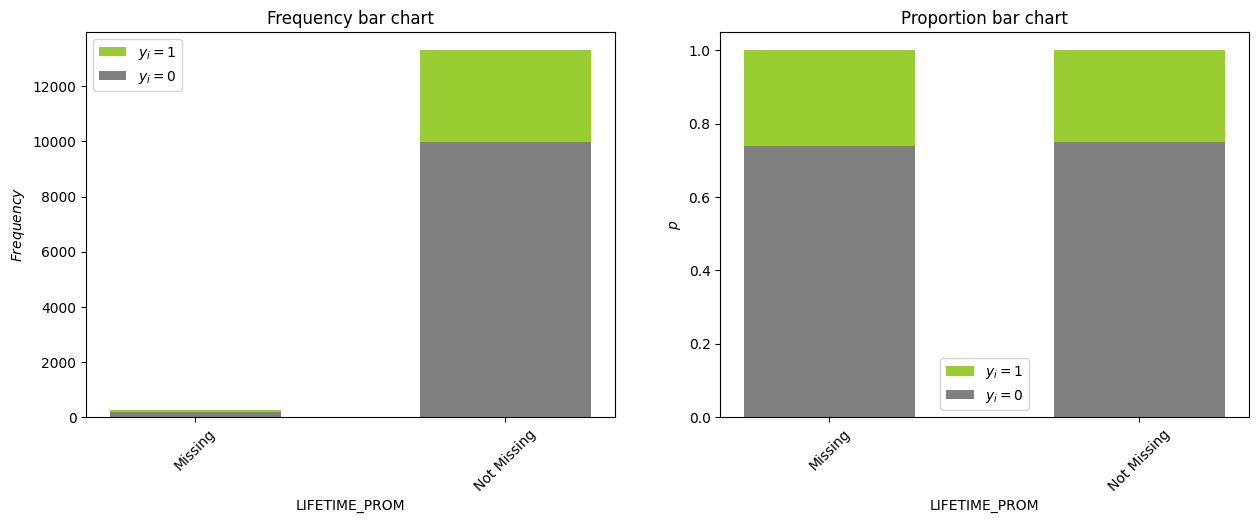

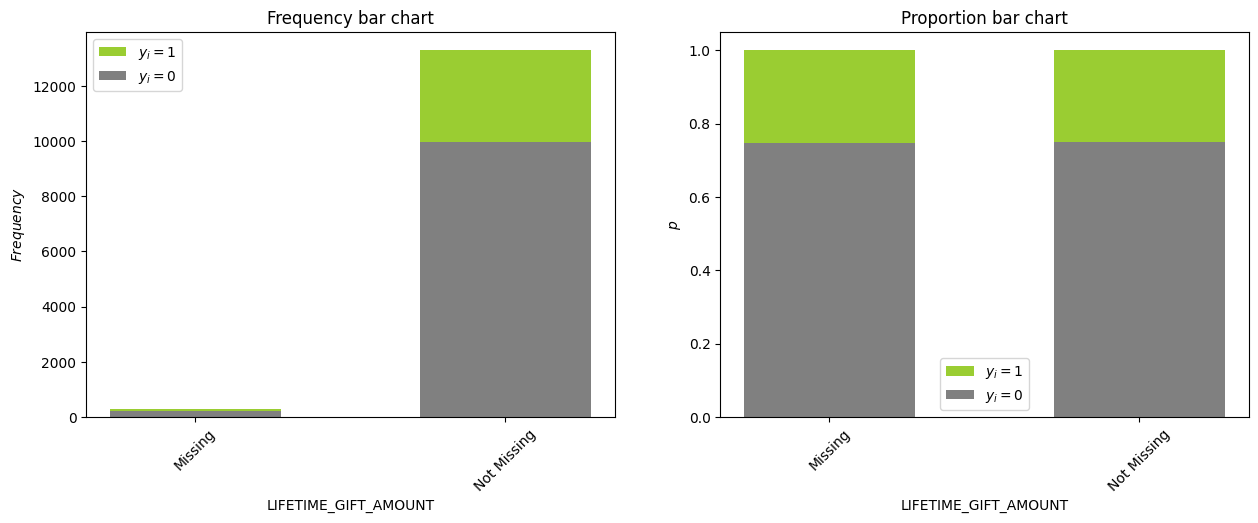

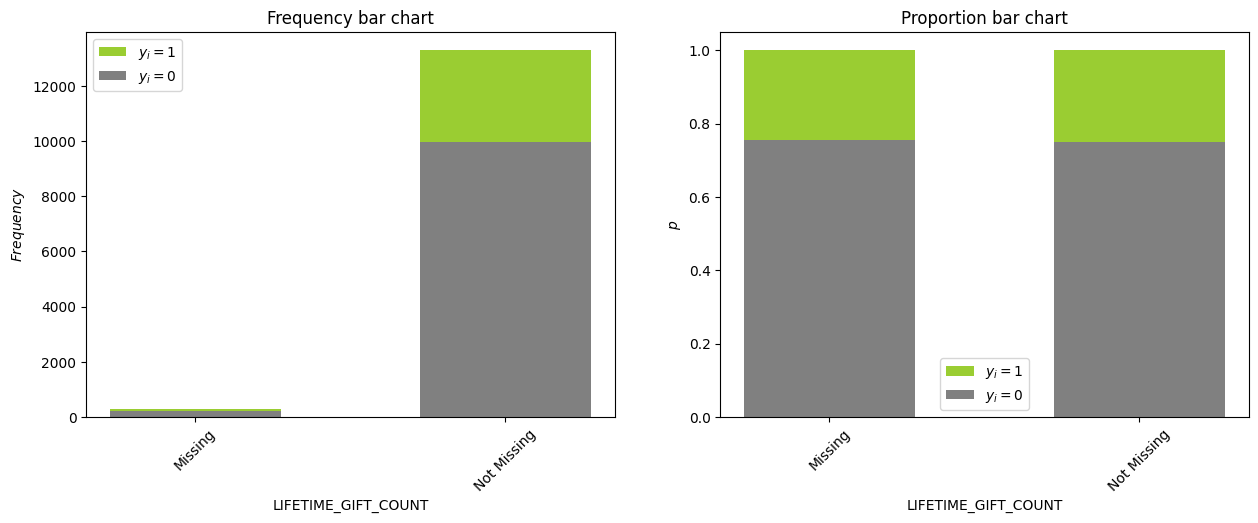

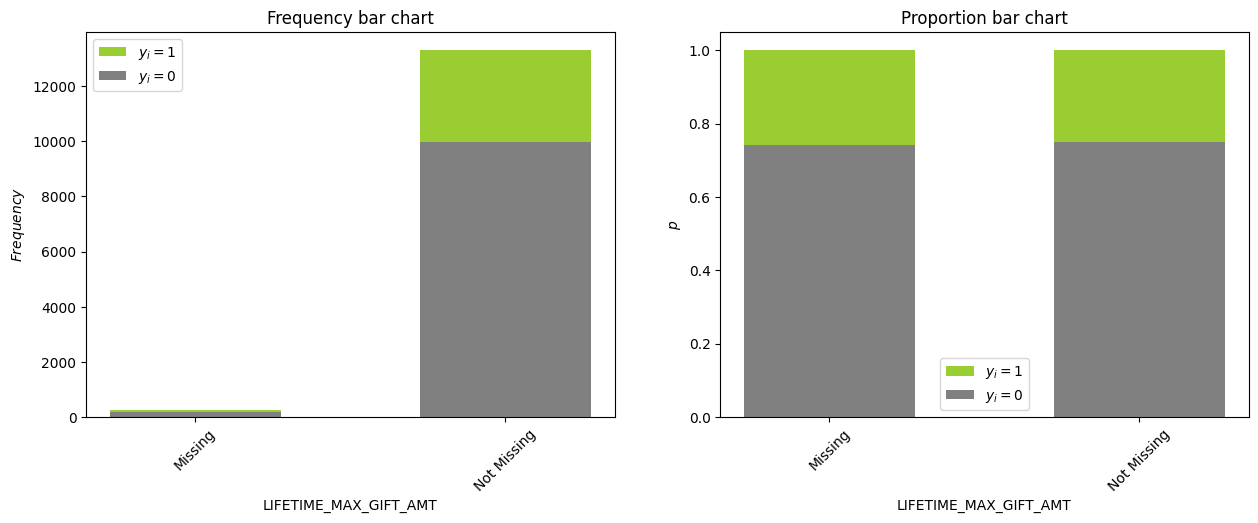

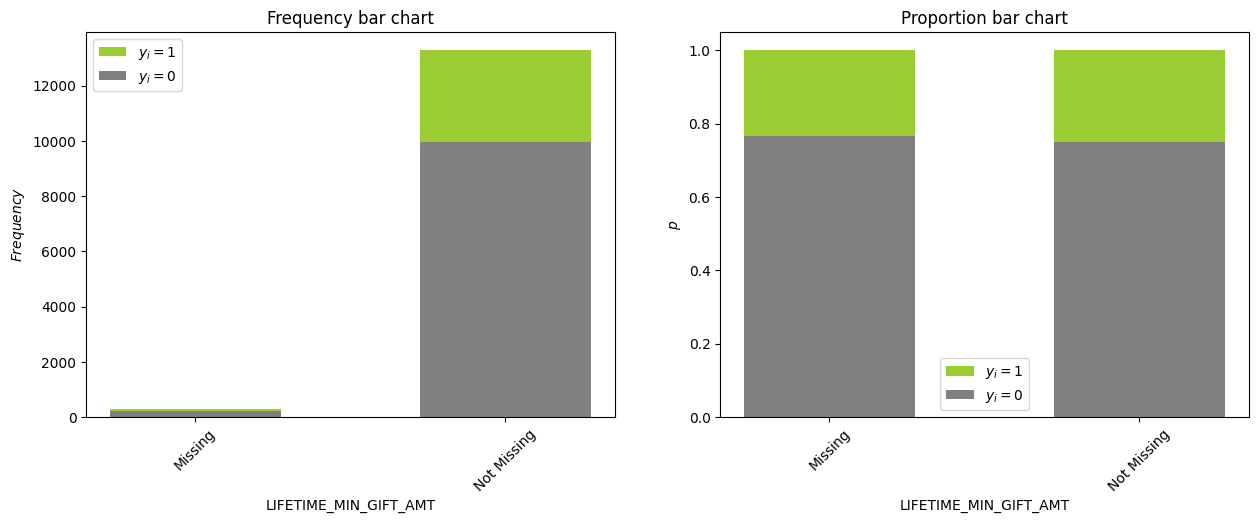

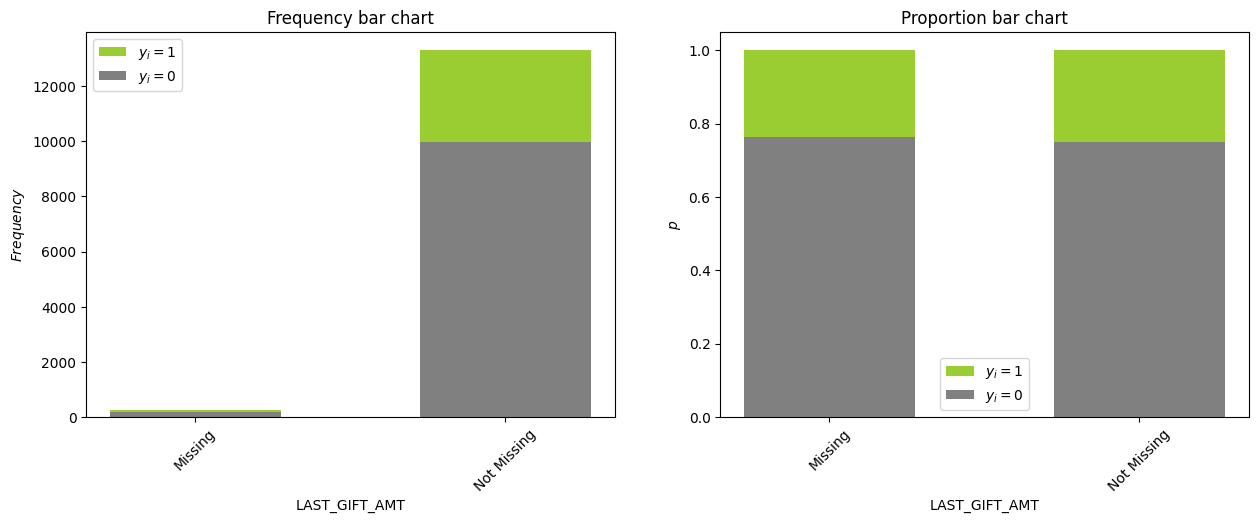

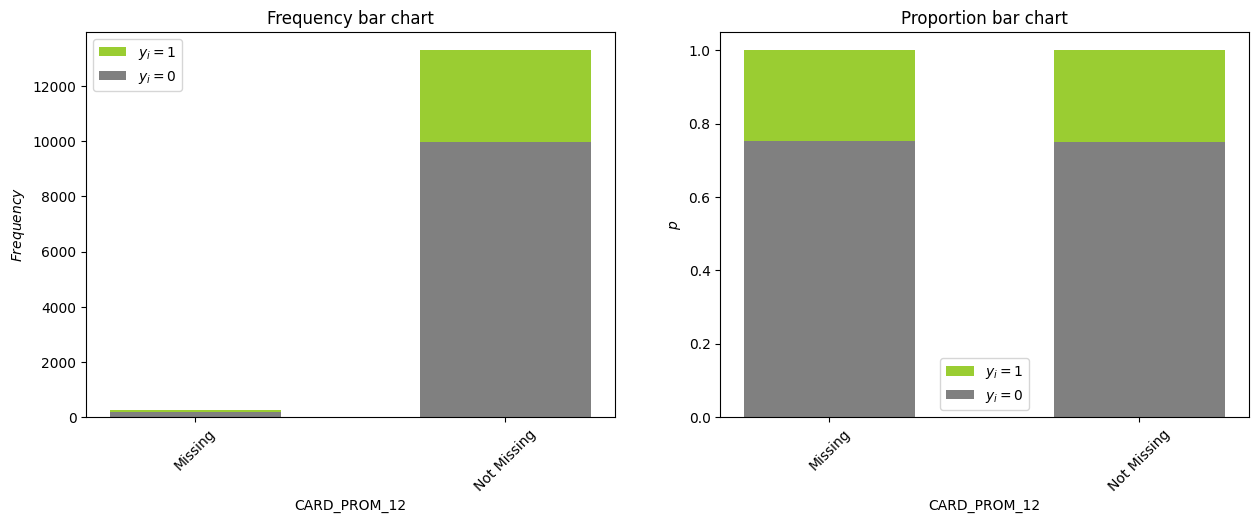

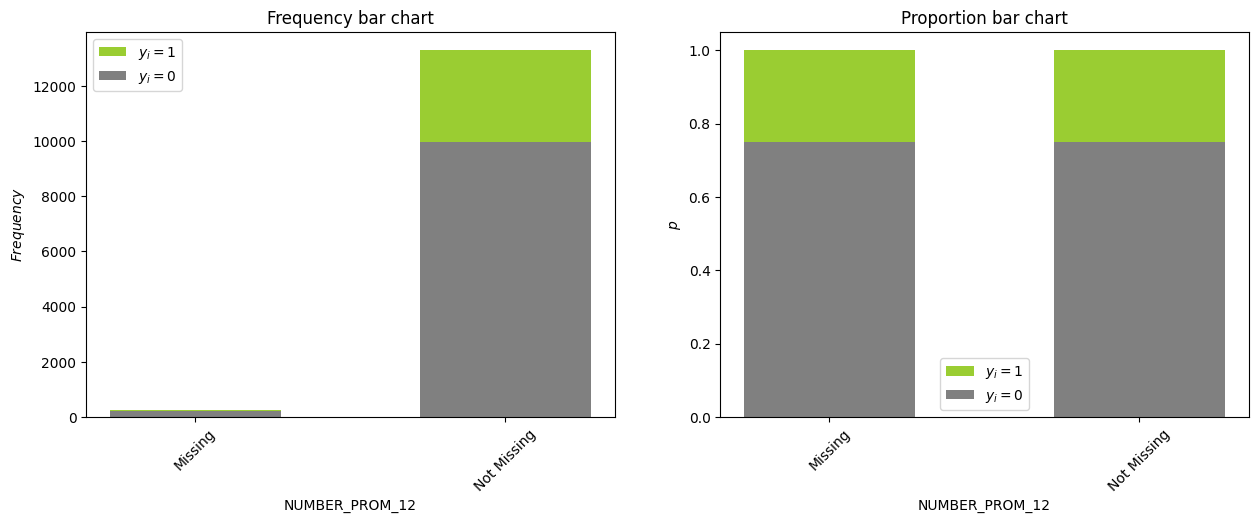

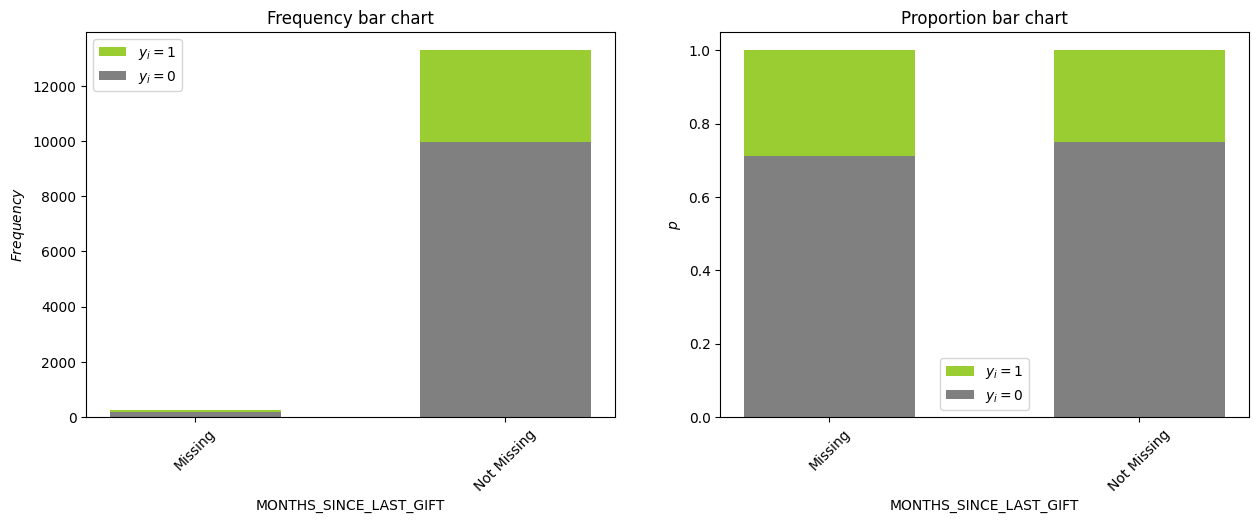

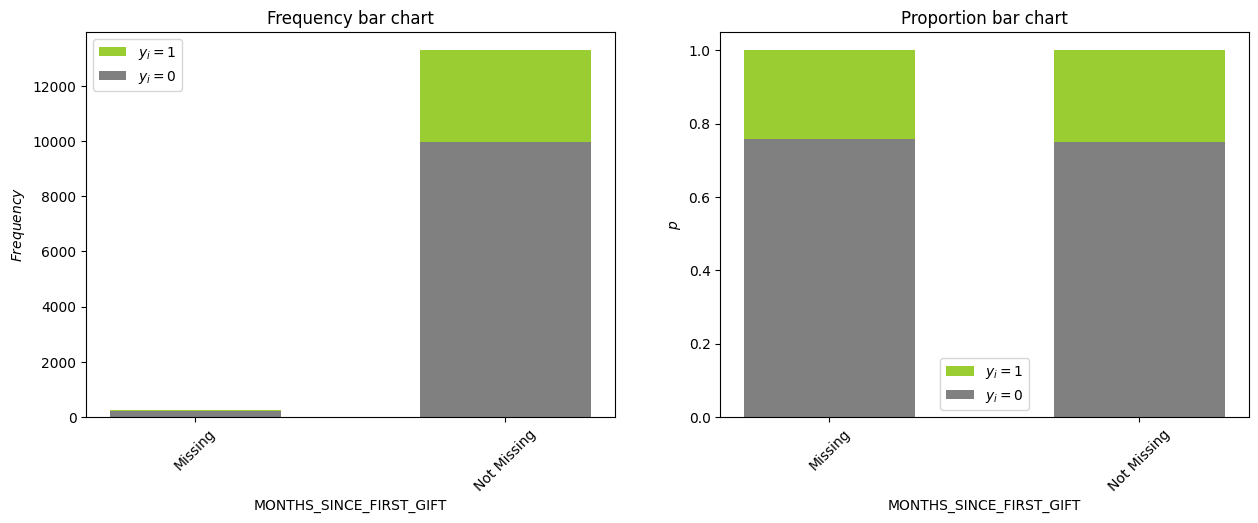

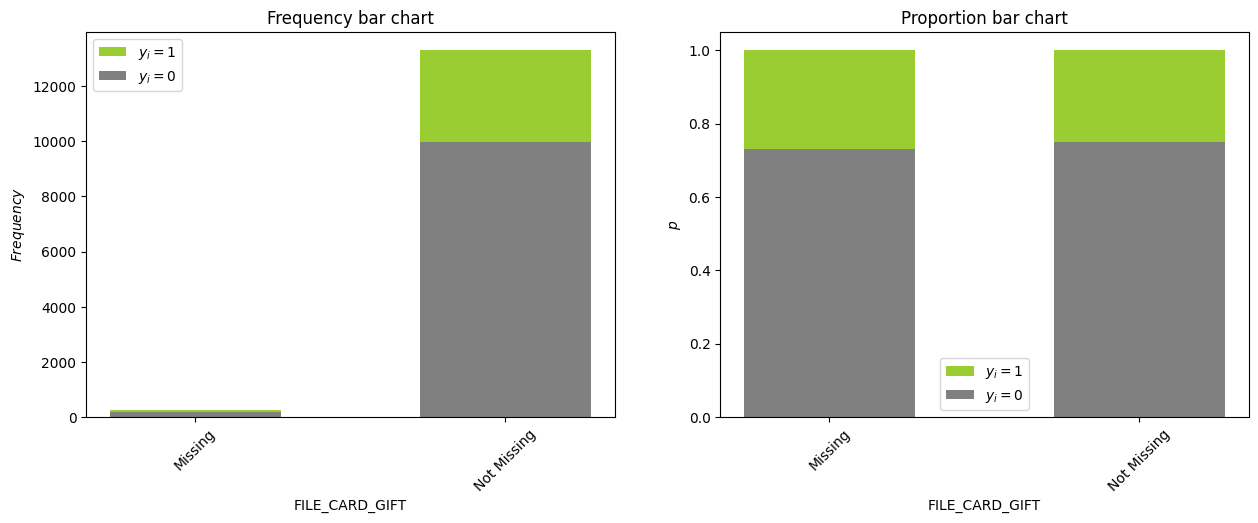

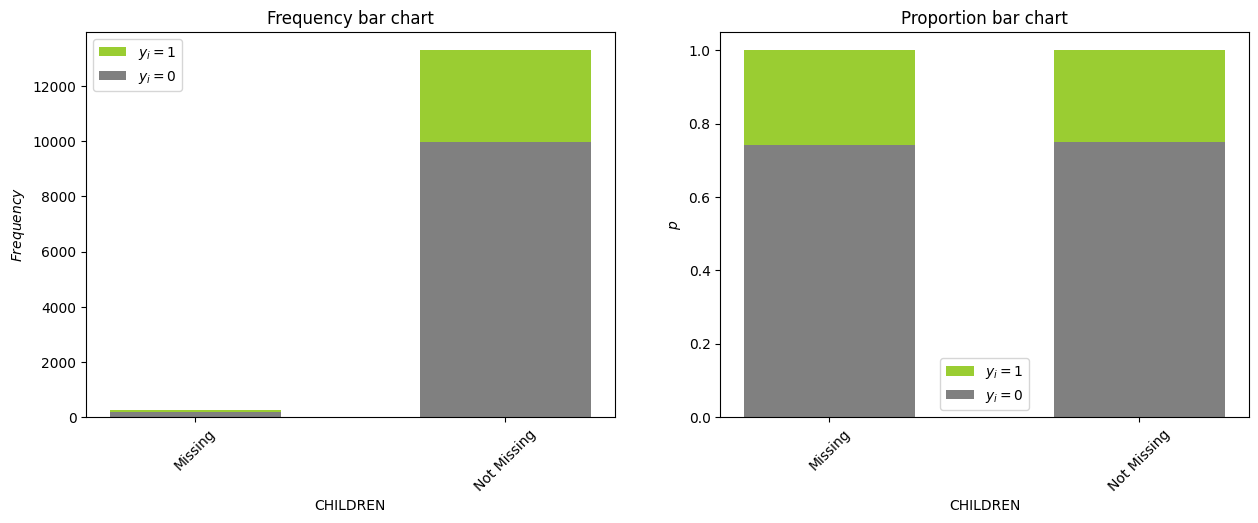

In [14]:
bar_charts_categorical(train[cat_cols + num_cols].isna().replace({True: 'Missing', False: 'Not Missing'}).join(train['TARGET_B']), cat_cols + num_cols, 'TARGET_B')

From the plots above we can conlude that missing values in any of the features are not direct predictors of the target, since the proportion of the target is similar across observations with and without missing data. <p> Now, that we have analyzed the existence of missing values in our data, we're going to start looking deeper into the features we have in our data.

## 4.2. <a id='toc4_2_'></a>[Categorical columns](#toc0_)

In this section categorical columns will be explored for potential data quality issues or insights.


### 4.2.1. <a id='toc4_2_1_'></a>[Value consistency evaluation](#toc0_)

As a first step, we'll check the all of unique values for each of our variables to look for inconsistencies our unexpected values.

In [15]:
for col in cat_cols:
    print(f'{col} : {train[col].unique().tolist()}')

URBANICITY : ['T', 'R', 'U', 'C', nan, 'S', '?']
SES : ['2', '3', '1', '4', nan, '?']
HOME_OWNER : ['H', 'U', nan]
DONOR_GENDER : ['M', 'F', 'U', nan]
INCOME_GROUP : [5.0, nan, 4.0, 6.0, 3.0, 2.0, 1.0, 7.0, 9.503279718784624, -1.737976712944631]
WEALTH_RATING : [nan, 4.0, 1.0, 5.0, 2.0, 0.0, 7.0, 6.0, 9.0, 8.0, 3.0, 13.451898003766887, -3.752821118381721]
PEP_STAR : [0.0, 1.0, nan, -0.5298718146873891, 2.004584679238949]
RECENT_STAR_STATUS : [0.0, 1.0, 6.0, nan, -7.809472848272476, 10.0, 3.0, 7.0, 5.0, 18.0, 12.0, 4.0, 11.0, 16.0, 15.0, 19.0, 8.587873099593457, 8.0, 13.0, 2.0, 14.0, 21.0, 9.0, 17.0, 22.0, 20.0]
RECENCY_STATUS_96NK : ['A', 'N', 'S', 'E', 'F', nan, 'L']



There are some clear takeaways from the unique values for our categorical columns:
+ Our analysis of SES, WEALTH_RATING and INCOME_GROUP as ordinal variables seems to be confirmed as these are already numerically encoded in an ordinal manner. Additionally the nature of these columns as ratings based on socioeconomic characteristics also fit the logic of an ordinal categorical variable.
+ Additionally the variables that use numerical encondings (ordinal and binary) all have a set of values which are either negative, stragely long decimals or both. These values are probably erroneous and likely result from the compilation of the data from the original set of donations. We'll look into this with our numerical variables as well.
+ There are two variables (URBANICITY, SES) with a "?" value, which we're going to consider missing values. This explains why SES was assigned a string datatype.
+ The HOME_OWNER variable as expected from the variable description is in reality a binary flag variable since it only contains H for homeowner, U for unknown, which is essentially a missing value and actual missing values. In our model pipelines
we will transform this into a binary variable where H will be 1 and U or NaN will be 0.
+ The DONOR_GENDER variable contains 3 categories, M and F for Male and Female and U category which likely represents unspecified. We're gonna consider it a valid category as it's likely a conscious decision of the donor not to share the information rather than a value which wasn't captured.
+ The description of the SES variable mentions 5 categories, but only 4 levels appear in the train.
+ The RECENT_STAR_STATUS feature is described as an indicator of whether the donor has reached STAR status within the last 4 years, and thus should be a binary variable, yet it contains seemingly correct values up to 22. This could likely be due to incorrect values or an outdated variable description for a case where the variable now stores a count of times the donor achieved STAR status and not just whether or not the donor achieved it. <p>

### 4.2.2. <a id='toc4_2_2_'></a>[Distributions and target proportions](#toc0_)

Below, the distributions of categories within each variable as well as the proportion of the target within each category will be evaluated.

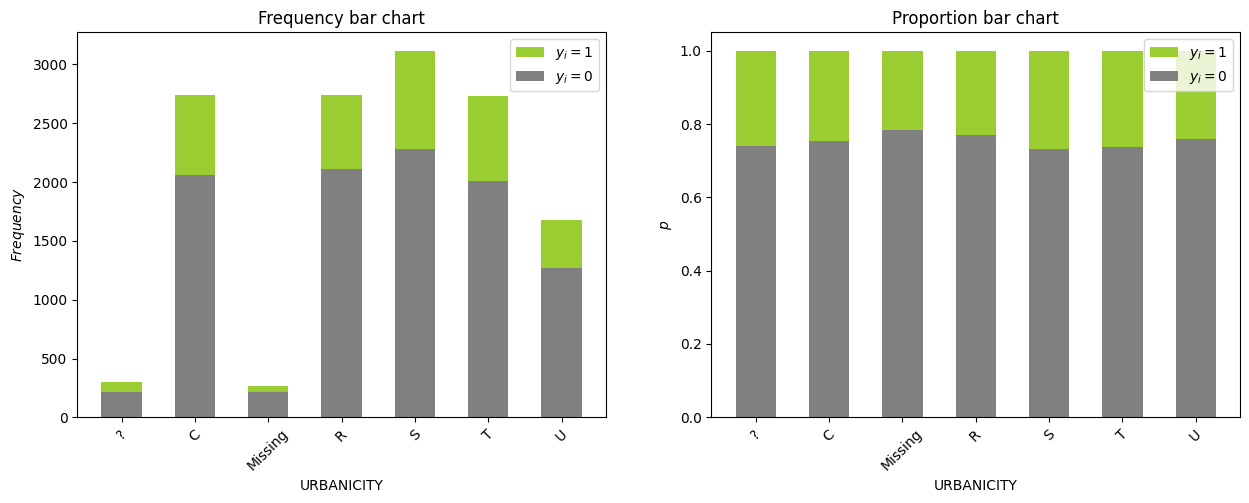

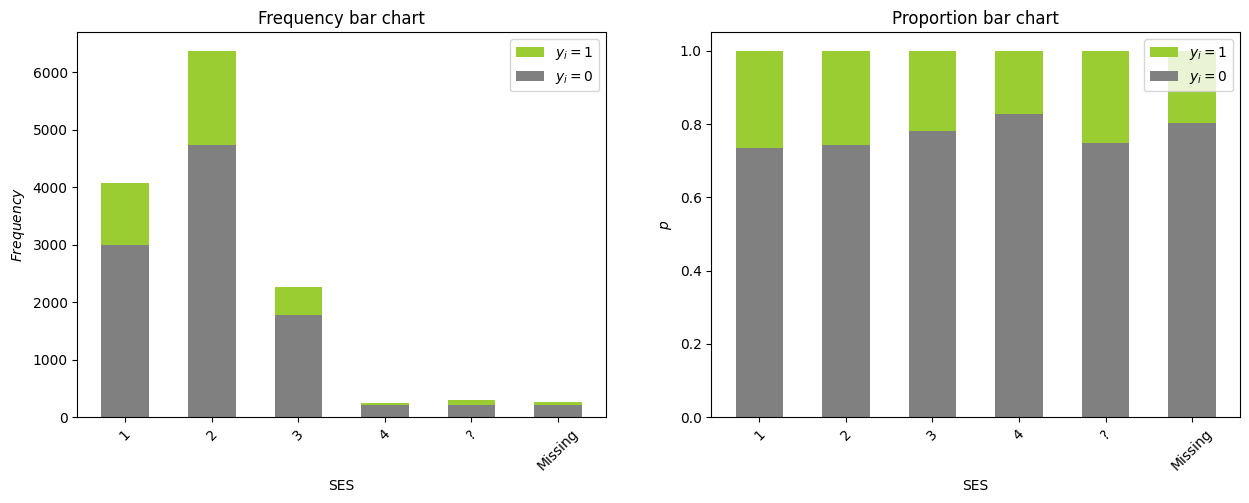

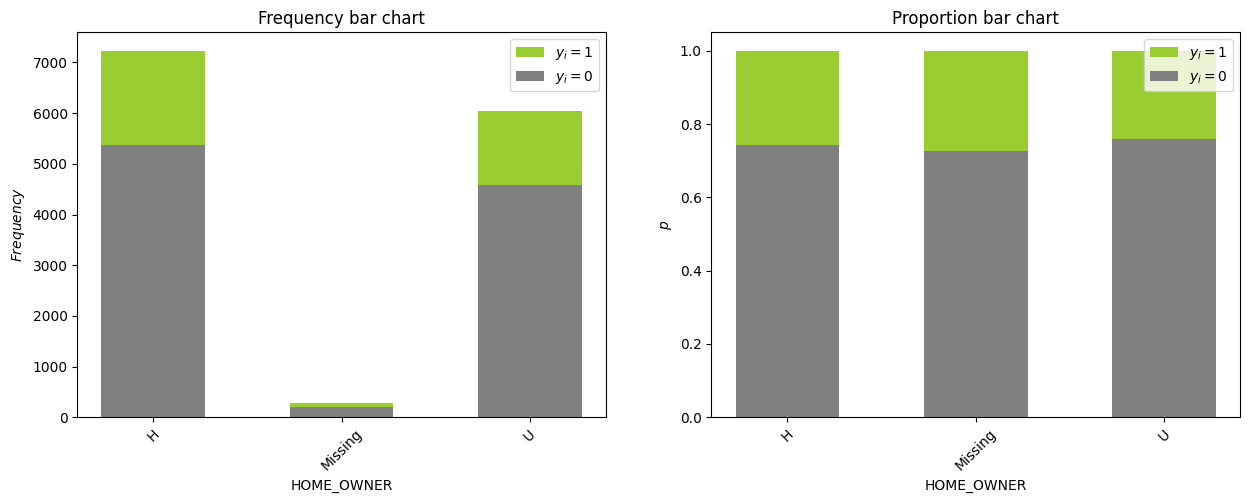

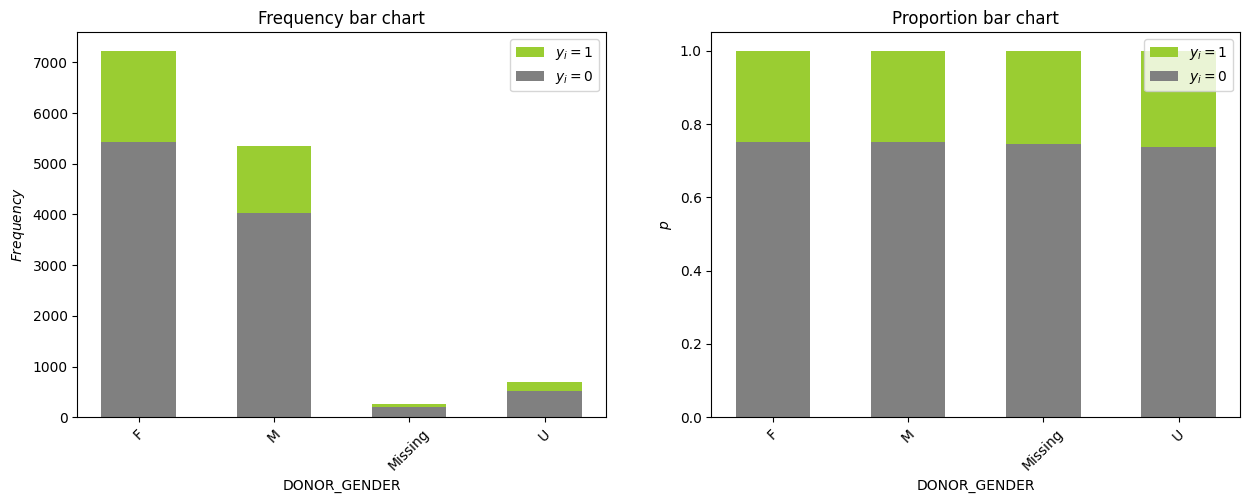

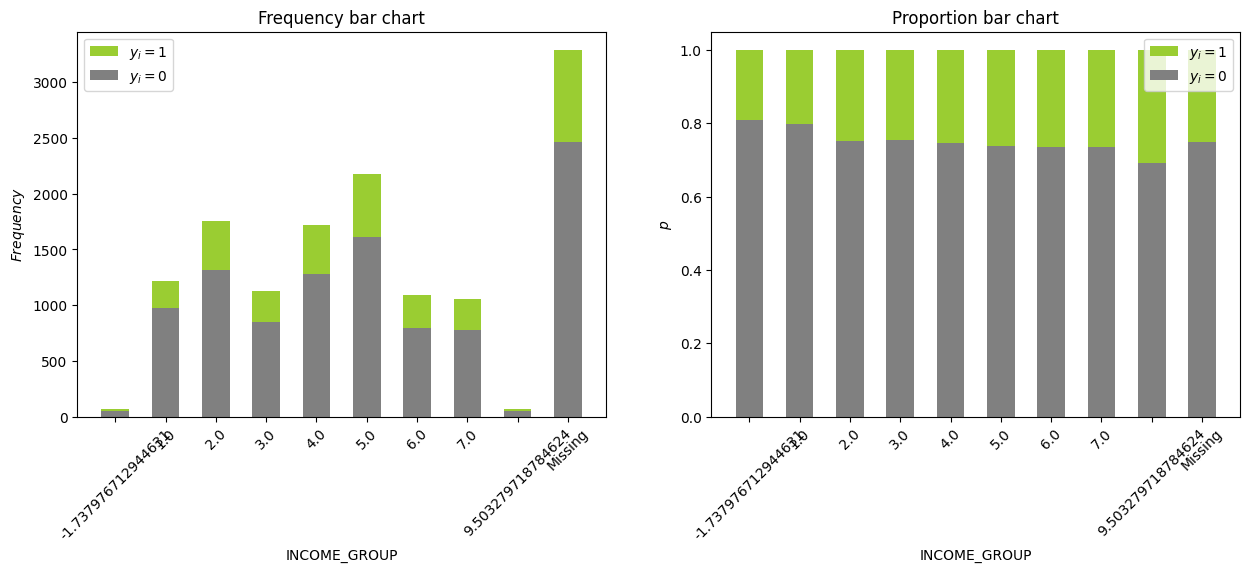

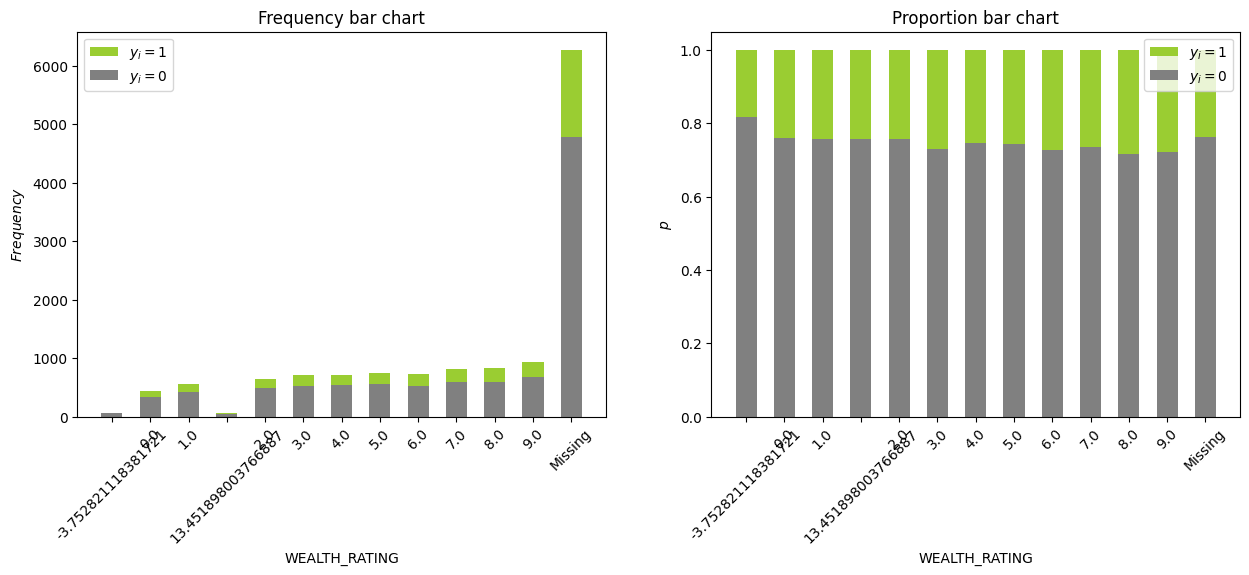

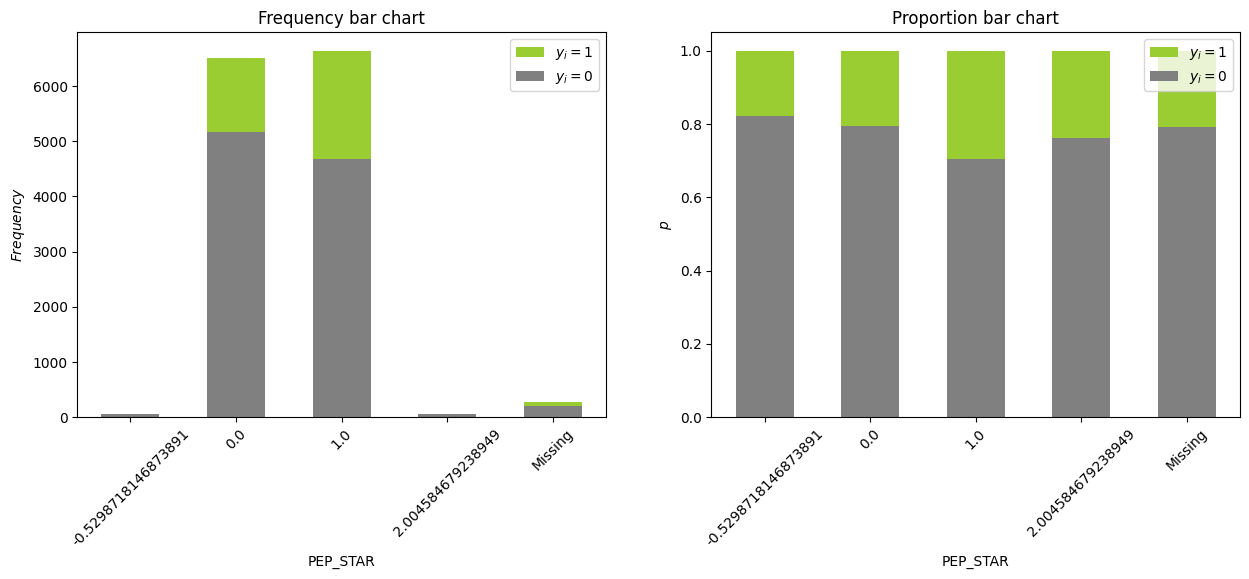

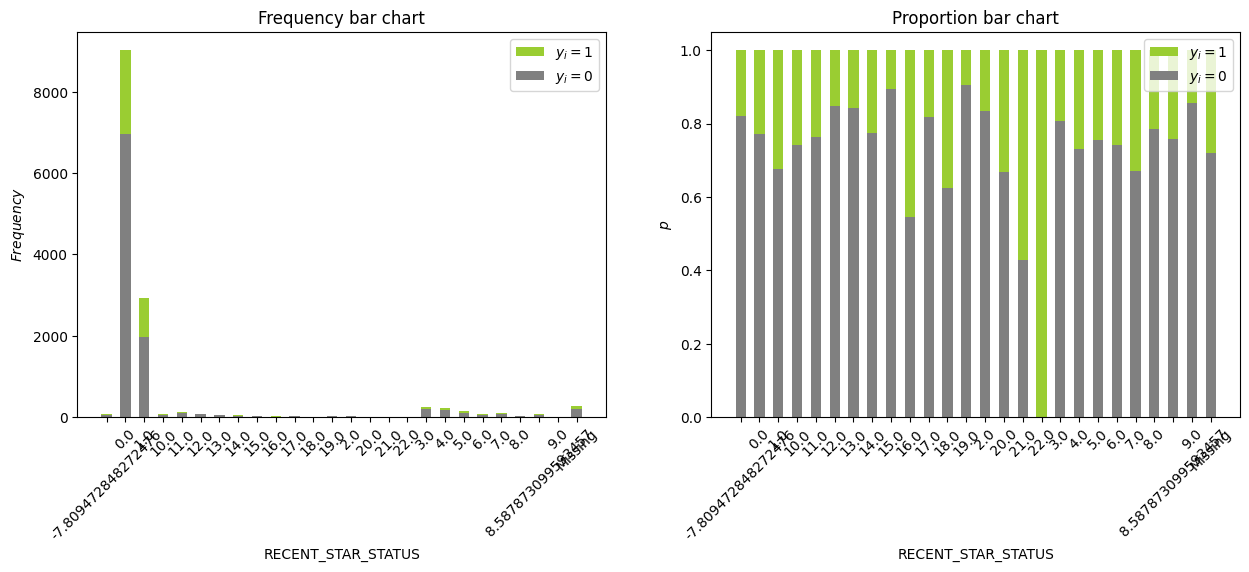

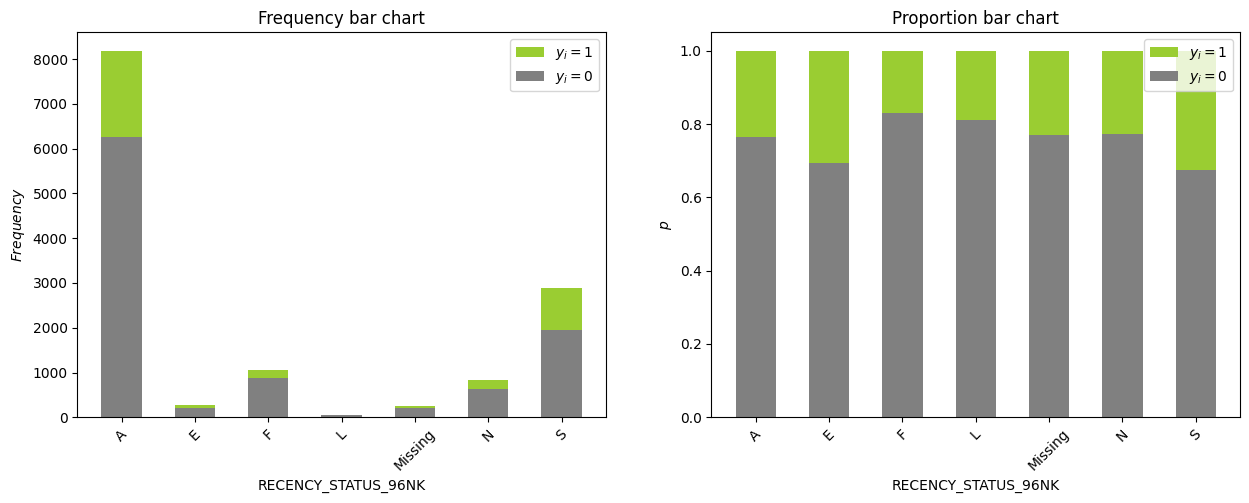

In [16]:
# We use the astype to allow us to use the fillna to create th bar missing values
# since some of our categorical variables are oridnally encoded and thus have been
# assinged numeric traintypes when importing
bar_charts_categorical(train.astype({col : 'str' for col in cat_cols}).fillna('Missing'), cat_cols, 'TARGET_B')

Looking at plots above there are a few relevant insights:
+ The distribution of the URBANICITY variable is not uniform with S for Suburban being slightly more common and U for Urban less common, the other three categories are found in similar quantities in the train. There are very small variations in the proportion of the target between categories even comparing to missing values, they're all between 0.7 and 0.8, around the overall proportion of the targe in the data.
+ Within the SES variable, level 2 is by far the most common, followed by level 1 and then level 3. Level 4 is quite uncommon. Again, there are small differences between the proportion of the target across categories, but they're all once again very close to the global value.
+ For the HOME_OWNER variable H for homeowner is slightly more common than Unknown, but the target proportion across both (and missing values) is essentially identical. This validates our plan to transform this into a binary variable from above.
+ The DONOR_GENDER variable tells us that there are more women in our data (F) than men (M) and only a relatively small amount of donors chose not to specify their gender (U). The target proportions across the three categories and missing values are essentially identical. Given the small amount of categories, the identical target distribution and the fact that ordinally enconding gender is not very logical, one-hot encoding the gender is the best option.
+ The INCOME_GROUP has a large amount of missing values as well as the strage decimal values mentioned above. Within the acceptable values there is some discrepencies in terms of counts with level 5 being the most common followed by 2 and 4 with similar presence and finally the 4 remaining levels which also appear in similar amounts. Once again, there are some fluctuations of the target proportion across categories, missing values and strange decimals, but these are small and around the global proportion of the dataset.
+ The WEALTH_RATING contains a very large amount of missing values, almost 50% and also the strange decimal values. The distribution among the valid categories of the variable is not uniform but it is quite stable. The target proportion across all of the values is once again very similar with some variation.
+ Slightly more donors  have reached STAR status comapring to those that haven't (STAR_STATUS), there are also missing values and more decimal values. Interestingly, the proportion of the target is a bit lower among those who have never achieved STAR status.  
+ As mentioned above the RECENT_STAR_STATUS contains missing values and a lot of different unexpected values, although in reality these are far less common than the expected 0 and 1 values, within which the number of donors who haven't achieved STAR status in the last 4 years is far more common. Between these two, much like the STAR_STATUS variable the proportion of the target is lower among those who have achieved it. Looking at the proportions for other values isn't very relevant as they are so uncommon that the proportion will not be a trustworthy indicator.
+ Finally, from the RECENCY_STATUS_96NK variable we can conclude that the large majority of donors are active (A) and a good amount are STAR donors (S), new (N) and first time (F) donors appear in smaller amounts and Lapsing (L) or Inactive (E) donor are quite rare (less common than missing values). Looking at the target proportions there are differences across classes, interestingly donors without a status (Missing) and Active donors share extremely similar proportions, thus indicating that using the mode (A - Active) to impute them is probably a safe idea. Contrarily to expectations, Lapsing and Inactive donors who receive this classification for not donationg for 12+ and 24+ months respectively actually have registered instances of donating to last year's camapaign, this likely indicates that the Recency Status assessment was performed before that campaign and the donors were re-engaged with the CSA in that particular campaign. 

### 4.2.3. <a id='toc4_2_3_'></a>[Statistical test - Chi-square independence test](#toc0_)

In this section, we're gonna preview the 2 statistical tests, Chi-square independence test and ANOVA test, we will use within our pipeline for categorical feature selection. This is purely informational since we're using crossvalidation for our modeling stage and distributions will change from fold to fold, this process must be included within the pipeline and no definitive conclusions can be taken from the analysis on the full training dataset. Some insights can still be extracted however. <p>
For both tests, we're going to consider a 5% significance level as that is the conventionally accepted value.

In [17]:
y = train['TARGET_B']
res = pd.DataFrame(columns=['chi2'])
for var in cat_cols:
    # If p-value < 0.05, reject H0 (similarity across groups)
    # and keep feature
    if chi2_contingency(pd.crosstab(y, train[var]))[1] < 0.05:
        res.loc[var, 'chi2'] = 'Keep'
    else:
        res.loc[var, 'chi2'] = 'Discard'
res

,chi2
URBANICITY,Keep
SES,Keep
HOME_OWNER,Keep
DONOR_GENDER,Discard
INCOME_GROUP,Keep
WEALTH_RATING,Discard
PEP_STAR,Keep
RECENT_STAR_STATUS,Keep
RECENCY_STATUS_96NK,Keep


## 4.3. <a id='toc4_3_'></a>[Numerical Columns](#toc0_)

In this section, an exploration of numerical columns will be performed, searching for data quality issues and potential insights.

## Descriptive Statistics

We're going to start by looking at the general descriptive statistics of the variables.

In [19]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
DONOR_AGE,10006.0,58.814086,17.568008,0.000000,46.000,60.000,73.000,108.946450
MEDIAN_HOME_VALUE,13294.0,1081.099146,1004.015872,-2187.526674,517.000,753.000,1247.000,6000.000000
MEDIAN_HOUSEHOLD_INCOME,13290.0,342.714746,172.478153,-190.662683,232.000,312.000,420.000,1500.000000
PCT_OWNER_OCCUPIED,13292.0,69.649793,22.459383,0.000000,59.000,76.000,85.000,134.837044
PER_CAPITA_INCOME,13289.0,15917.009156,9174.923246,-12823.750149,10887.000,13880.000,18434.000,174523.000000
PCT_ATTRIBUTE1,13286.0,1.079089,5.402809,-15.109374,0.000,0.000,0.000,97.000000
PCT_ATTRIBUTE2,13299.0,30.646003,11.917120,-3.918837,25.000,31.000,37.000,85.000000
PCT_ATTRIBUTE3,13288.0,29.592675,15.752201,-17.245877,20.000,29.000,39.000,99.000000
PCT_ATTRIBUTE4,13295.0,32.858382,18.561128,-22.613054,21.000,32.000,43.000,99.000000
FREQUENCY_STATUS_97NK,13278.0,1.993986,1.147577,-1.363824,1.000,2.000,3.000,5.279946


Some 

## Gift Amount consistency


We're now going to check the consistency of gift amount features. Ensuring that the relationships between the values in these columns respect the expectations and requirements of their logic.

In [22]:
train[train['LIFETIME_MAX_GIFT_AMT'] < train['LIFETIME_MIN_GIFT_AMT']]


,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
129715,6.0,3.0,37.0,M,2.000000,2.0,H,6.0,20.0,13.0,...,25.00,1.0,0.125,1.0,0.056,0.0,1,S,NaN,0
140492,5.0,4.0,NaN,M,12.000000,1.0,H,5.0,20.0,31.0,...,20.00,0.0,0.000,1.0,0.048,12.0,1,T,8.0,0
54441,6.0,0.0,56.0,F,5.000000,1.0,H,4.0,25.0,23.0,...,25.00,0.0,0.000,1.0,0.053,15.0,3,R,4.0,1
1970,6.0,2.0,NaN,F,11.000000,2.0,U,6.0,10.0,31.0,...,6.17,4.0,0.364,6.0,0.273,0.0,2,T,NaN,0
61222,6.0,4.0,78.0,F,3.000000,1.0,H,6.0,16.0,17.0,...,15.00,1.0,0.125,2.0,0.111,0.0,1,S,8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25272,6.0,3.0,NaN,U,19.092897,3.0,H,5.0,12.0,12.0,...,11.00,3.0,0.429,3.0,0.200,0.0,1,T,NaN,0
94390,6.0,4.0,84.0,F,10.000000,2.0,H,1.0,5.0,33.0,...,10.33,2.0,0.222,3.0,0.150,1.0,3,U,5.0,0
132239,6.0,0.0,87.0,M,4.000000,3.0,U,1.0,10.0,19.0,...,10.67,1.0,0.125,3.0,0.176,0.0,2,R,0.0,0


From the cell above, we can verify that there are 126 rows where the minimum gift amount is higher than the maximum amount.

In [23]:
train[(train['LIFETIME_MAX_GIFT_AMT'] < 0) & (train['LIFETIME_MAX_GIFT_AMT'] < train['LIFETIME_MIN_GIFT_AMT'])]['LIFETIME_MAX_GIFT_AMT'].value_counts()

LIFETIME_MAX_GIFT_AMT
-33.606782    63
Name: count, dtype: int64

In [24]:
train[(train['LIFETIME_MAX_GIFT_AMT'] > 0) & (train['LIFETIME_MAX_GIFT_AMT'] < train['LIFETIME_MIN_GIFT_AMT'])]['LIFETIME_MIN_GIFT_AMT'].value_counts().sort_index()

LIFETIME_MIN_GIFT_AMT
31.628258    63
Name: count, dtype: int64

It's now clear that a lower maximum gift amount only occurs when the maximum gift amount is either below 0 and has 3 decimal places (63 rows), and thus clearly an erroneous value, or when the minimum gift amount is rounded to  31,628 (63 rows), which is also an erroneous value since a rounded donation amount can't have 3 decimal places, since the lowest unit of currency is cents (2 decimal places).

In [25]:
train[train['LIFETIME_MAX_GIFT_AMT'] < train['LAST_GIFT_AMT']]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
129715,6.0,3.0,37.0,M,2.0,2.0,H,6.0,20.000000,13.0,...,25.00,1.000000,0.125000,1.0,0.056,0.0,1,S,NaN,0
84264,6.0,4.0,41.0,M,4.0,4.0,H,4.0,52.703845,12.0,...,11.60,4.000000,0.500000,5.0,0.385,0.0,2,T,NaN,0
35463,4.0,2.0,60.0,M,8.0,1.0,H,7.0,52.703845,28.0,...,20.00,6.336365,0.286000,2.0,0.125,0.0,1,C,8.0,1
65365,4.0,3.0,79.0,F,1.0,1.0,U,1.0,52.703845,11.0,...,15.00,0.000000,0.000000,1.0,0.063,0.0,3,C,5.0,0
128987,6.0,1.0,58.0,F,5.0,1.0,H,4.0,52.703845,26.0,...,37.67,2.000000,0.182000,3.0,0.143,0.0,1,U,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37716,6.0,1.0,31.0,F,4.0,4.0,U,4.0,52.703845,15.0,...,7.50,3.000000,0.300000,6.0,0.300,0.0,3,U,NaN,0
175000,5.0,0.0,64.0,F,6.0,1.0,H,3.0,52.703845,24.0,...,17.33,2.000000,-0.368988,3.0,0.150,7.0,2,T,3.0,1
2113,6.0,1.0,57.0,F,10.0,2.0,U,7.0,52.703845,25.0,...,9.67,4.000000,0.364000,6.0,0.300,1.0,1,S,3.0,0


In [26]:
train[train['LIFETIME_MIN_GIFT_AMT'] > train['LAST_GIFT_AMT']]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
140492,5.0,4.0,NaN,M,12.00000,1.0,H,5.0,20.0000,31.0,...,20.00,0.0,0.000,1.0,0.048,12.0,1,T,8.0,0
36170,4.0,0.0,69.0,F,2.00000,3.0,H,5.0,-21.8336,10.0,...,7.50,1.0,0.167,2.0,0.125,0.0,1,NaN,NaN,0
54441,6.0,0.0,56.0,F,5.00000,1.0,H,4.0,25.0000,23.0,...,25.00,0.0,0.000,1.0,0.053,15.0,3,R,4.0,1
1970,6.0,2.0,NaN,F,11.00000,2.0,U,6.0,10.0000,31.0,...,6.17,4.0,0.364,6.0,0.273,0.0,2,T,NaN,0
39155,NaN,4.0,82.0,M,1.00000,1.0,NaN,2.0,-21.8336,6.0,...,15.00,1.0,0.250,1.0,0.100,0.0,2,C,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154198,6.0,0.0,56.0,F,2.00000,2.0,U,NaN,-21.8336,10.0,...,10.67,2.0,0.333,3.0,0.231,0.0,2,T,NaN,0
155158,4.0,4.0,41.0,F,0.00000,1.0,U,NaN,-21.8336,9.0,...,12.50,0.0,0.000,2.0,0.154,0.0,3,U,NaN,0
13976,4.0,4.0,NaN,F,1.00000,1.0,H,5.0,20.0000,5.0,...,20.00,1.0,0.500,1.0,0.200,0.0,2,U,NaN,0


Additionally, there are 124 rows where the maximum gift amount is lower than the last gift amount and 127 rows where the minimum gift amount is higher than the last gift amount.

In [27]:
train[(train['LIFETIME_MAX_GIFT_AMT'] < 0) & (train['LIFETIME_MAX_GIFT_AMT'] < train['LAST_GIFT_AMT'])]['LIFETIME_MAX_GIFT_AMT'].value_counts()

LIFETIME_MAX_GIFT_AMT
-33.606782    61
Name: count, dtype: int64

In [28]:
train[(train['LIFETIME_MAX_GIFT_AMT'] > 0) & (train['LIFETIME_MAX_GIFT_AMT'] < train['LAST_GIFT_AMT'])]['LAST_GIFT_AMT'].value_counts().sort_index()

LAST_GIFT_AMT
52.703845    63
Name: count, dtype: int64

We can see that a lower maximum gift amount only occurs when the maximum gift amount is either below 0 and has 3 decimal places (61 rows), and thus clearly an erroneous value, or when the last gift amount is rounded to 52,704 (63 rows), which is also an erroneous value since a rounded donation amount can't have 3 decimal places, since the lowest unit of currency is cents (2 decimal places).

In [29]:
train[(train['LAST_GIFT_AMT'] < 0) & (train['LIFETIME_MIN_GIFT_AMT'] > train['LAST_GIFT_AMT'])]['LAST_GIFT_AMT'].value_counts()

LAST_GIFT_AMT
-21.8336    64
Name: count, dtype: int64

In [30]:
train[(train['LAST_GIFT_AMT'] > 0) & (train['LIFETIME_MIN_GIFT_AMT'] > train['LAST_GIFT_AMT'])]['LIFETIME_MIN_GIFT_AMT'].value_counts().sort_index()

LIFETIME_MIN_GIFT_AMT
31.628258    63
Name: count, dtype: int64

It is clear that much like the above case, higher minimum gift amounts when compared to the last gift amount come from erroneous values, wither 3 decimal place negative last gift amounts (64 rows) or the same rounded 3 decimal 31,628 value for the minimum gift amount present above.

In [31]:
train[train['LIFETIME_MAX_GIFT_AMT'] < (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT'])]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
129715,6.0,3.0,37.0,M,2.00000,2.0,H,6.0,20.0,13.0,...,25.000000,1.0,0.125,1.0,0.056,0.0,1,S,NaN,0
37768,6.0,4.0,33.0,M,4.00000,2.0,U,5.0,14.0,24.0,...,13.000000,0.0,0.000,2.0,0.100,0.0,2,C,7.0,0
28557,4.0,4.0,77.0,F,10.00000,1.0,H,4.0,15.0,30.0,...,15.000000,0.0,0.000,1.0,0.056,0.0,2,R,7.0,0
61222,6.0,4.0,78.0,F,3.00000,1.0,H,6.0,16.0,17.0,...,15.000000,1.0,0.125,2.0,0.111,0.0,1,S,8.0,0
105963,6.0,1.0,56.0,F,3.00000,4.0,U,NaN,12.0,14.0,...,11.000000,2.0,0.286,4.0,0.222,0.0,3,C,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37258,6.0,0.0,46.0,M,-10.09857,1.0,H,7.0,15.0,19.0,...,15.000000,1.0,0.111,2.0,0.100,12.0,1,C,9.0,0
23417,6.0,4.0,70.0,F,1.00000,1.0,H,5.0,50.0,17.0,...,42.500000,0.0,0.000,2.0,0.091,0.0,3,R,5.0,0
133136,4.0,1.0,NaN,M,1.00000,1.0,U,1.0,15.0,7.0,...,45.785087,1.0,0.250,1.0,0.083,0.0,NaN,R,NaN,0


In [32]:
train[train['LIFETIME_MIN_GIFT_AMT'] > (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT'])]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
18640,6.0,3.0,49.0,F,1.0,2.0,H,6.0,15.0,11.0,...,11.67,1.0,0.143,3.00000,0.214,0.0,1,T,NaN,0
140492,5.0,4.0,NaN,M,12.0,1.0,H,5.0,20.0,31.0,...,20.00,0.0,0.000,1.00000,0.048,12.0,1,T,8.0,0
177694,6.0,1.0,52.0,M,3.0,1.0,H,6.0,30.0,23.0,...,27.50,1.0,0.091,2.00000,0.095,0.0,1,T,5.0,0
175708,6.0,4.0,55.0,M,1.0,1.0,H,5.0,25.0,11.0,...,25.00,1.0,0.143,9.17005,0.133,0.0,2,S,NaN,1
2431,10.0,2.0,83.0,M,8.0,2.0,H,7.0,5.0,29.0,...,14.75,2.0,0.200,4.00000,0.190,0.0,3,R,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160012,6.0,0.0,73.0,M,4.0,3.0,U,NaN,15.0,NaN,...,13.00,2.0,0.182,5.00000,0.238,1.0,2,C,5.0,0
95059,6.0,2.0,70.0,F,6.0,2.0,H,4.0,10.0,25.0,...,23.67,3.0,0.273,3.00000,0.150,1.0,2,C,4.0,0
71146,6.0,0.0,23.0,F,1.0,4.0,U,3.0,10.0,11.0,...,9.33,1.0,0.143,3.00000,0.214,0.0,2,T,NaN,1


There are also 117 rows where the maximum gift amount is lower than the average lifetime gift amount and 232 rows where the minimum gift amount is higher.

In [ ]:
train[(train['LIFETIME_GIFT_AMOUNT'] < 0) & (train['LIFETIME_MIN_GIFT_AMT'] > (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_AMOUNT'].value_counts()

LIFETIME_GIFT_AMOUNT
-243.255927    71
Name: count, dtype: int64

In [ ]:
train[(train['LIFETIME_GIFT_COUNT'] < 0) & (train['LIFETIME_GIFT_AMOUNT'] > 0) & (train['LIFETIME_MIN_GIFT_AMT'] > (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_COUNT'].value_counts()

LIFETIME_GIFT_COUNT
-18.62906    55
Name: count, dtype: int64

In [ ]:
train[(train['LIFETIME_GIFT_AMOUNT'] > 0) & (train['LIFETIME_GIFT_COUNT'] > 0) & (data['LIFETIME_MIN_GIFT_AMT'] > (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT']))]['LIFETIME_MIN_GIFT_AMT'].value_counts().sort_index()

LIFETIME_MIN_GIFT_AMT
2.000000      2
3.000000      9
5.000000     21
6.000000      2
10.000000     5
15.000000     5
25.000000     4
30.000000     1
31.628258    57
Name: count, dtype: int64

In [ ]:
train[(train['LIFETIME_GIFT_AMOUNT'] > 0) & (train) & (train['LIFETIME_MIN_GIFT_AMT'] % 1 == 0) & (train['LIFETIME_MIN_GIFT_AMT'] > (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_COUNT'].value_counts().sort_index()

LIFETIME_GIFT_COUNT
36.079549    49
Name: count, dtype: int64

In [ ]:
train[(train['LIFETIME_MAX_GIFT_AMT'] < 0) & (train['LIFETIME_MAX_GIFT_AMT'] < (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT']))]['LIFETIME_MAX_GIFT_AMT'].value_counts()

LIFETIME_MAX_GIFT_AMT
-33.606782    57
Name: count, dtype: int64

In [ ]:
train[(train['LIFETIME_MAX_GIFT_AMT'] > 0) & (train['LIFETIME_MAX_GIFT_AMT'] < (train['LIFETIME_GIFT_AMOUNT'] / train['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_AMOUNT'].value_counts().sort_index()

LIFETIME_GIFT_AMOUNT
420.949039    60
Name: count, dtype: int64

We can see that a lower maximum gift amount or a higher minimum compared to the average, similarly to the situation above, only happens when one or more of the values are erroneous, either negative or inadmissibly long decimal. <p> The insights of this section clearly show us these variables and their relationships are affected by incorrect values, likely coming from the system calculation of the values during data collection. For this reason, it's clear that any negative or ininadmissibly long decimal value in any of 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT' and 'LAST_GIFT_AMOUNT' is incorrect and not based in any real informatopn, as such we will, when developing our pipeline replace them with a missing value.